# NGBoost hyperparameter tuning

In [1]:
# Load data

import pandas as pd
import numpy as np 

train_df = pd.read_parquet("data/train_data.parquet")

train_df.index = pd.to_numeric(train_df.index, errors="coerce")

cols_to_drop = ["issue_d", "earliest_cr_line"]
train_df = train_df.drop(columns=cols_to_drop, errors="ignore")

In [2]:
# Separate features and targets

train_full_X = train_df.drop(["target", "target_annual_roi"], axis=1)
train_full_y_cat = train_df["target"]
train_full_y_reg = train_df["target_annual_roi"]

# Drop datetime features from the feature set

cols_to_drop = ["issue_d", "earliest_cr_line"]
train_full_X = train_full_X.drop(columns=cols_to_drop, errors="ignore")

In [3]:
# Create subsets of the data for different training sizes - chronological order is preserved, so we take the last N rows for each subset

train_1k_X = train_full_X.tail(1000)
train_1k_y_cat = train_full_y_cat.tail(1000)
train_1k_y_reg = train_full_y_reg.tail(1000)

train_10k_X = train_full_X.tail(10000)
train_10k_y_cat = train_full_y_cat.tail(10000)
train_10k_y_reg = train_full_y_reg.tail(10000)

train_100k_X = train_full_X.tail(100000)
train_100k_y_cat = train_full_y_cat.tail(100000)
train_100k_y_reg = train_full_y_reg.tail(100000)

In [4]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import TargetEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline

cols_to_nominal_cat = train_df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Categorical columns:")
for col in cols_to_nominal_cat:
    print(f"- {col}")

cardinality = train_df[cols_to_nominal_cat].nunique()
threshold_for_ohe = 5

cols_for_ohe = cardinality[cardinality <= threshold_for_ohe].index.tolist()
cols_for_te = cardinality[cardinality > threshold_for_ohe].index.tolist()

ohe_categories = []
for col in cols_for_ohe:
    unique_cats = train_df[col].dropna().unique().tolist()
    ohe_categories.append(unique_cats)

ohe_transformer = OneHotEncoder(
    categories=ohe_categories, 
    drop="if_binary", 
    handle_unknown="ignore", 
    sparse_output=False
)

target_transformer_nominal = TargetEncoder(target_type="binary", smooth="auto")

numeric_preprocessor = ColumnTransformer(
    transformers=[
        ("ohe", ohe_transformer, cols_for_ohe),
        ("target_enc", target_transformer_nominal, cols_for_te)
    ],
    remainder="passthrough", 
    verbose_feature_names_out=False
).set_output(transform="pandas")

imputed_numeric_preprocessor = make_pipeline(
    numeric_preprocessor,
    SimpleImputer(strategy="median")
).set_output(transform="pandas")

gbdt_preprocessor = "passthrough"

Categorical columns:
- home_ownership
- verification_status
- purpose
- addr_state
- initial_list_status
- application_type
- disbursement_method


## Classification

[Parameters NGBoost](https://stanfordmlgroup.github.io/ngboost/1-useage.html)
[Parameters base learner](https://scikit-learn.org/1.6/modules/generated/sklearn.tree.DecisionTreeRegressor.html)

### 1k

In [5]:
# Check the dates of 1k subset to ensure all data is from same month

print(train_1k_X["issue_d_month"].unique())
print(train_1k_X["issue_d_year"].unique())

<IntegerArray>
[10]
Length: 1, dtype: Int64
<IntegerArray>
[2016]
Length: 1, dtype: Int64


In [6]:
import optuna
import numpy as np
import warnings
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import TimeSeriesSplit
from optuna.visualization import (
    plot_optimization_history, 
    plot_param_importances, 
    plot_parallel_coordinate
)
from optuna.samplers import TPESampler
from ngboost import NGBClassifier
from ngboost.distns import Bernoulli
from sklearn.tree import DecisionTreeRegressor
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.pipeline import make_pipeline


# Parameter tuning settings

timeout_seconds = 60*60*0.5
no_improvement_trials = 100

# Split the 1k dataset to evaluate on holdout after tuning
# Had problem with overfitting and extreme bad results on last 200 rows so switched the order

X_tuning = train_1k_X.tail(800)
y_tuning = train_1k_y_cat.tail(800)
X_val_holdout = train_1k_X.head(200)
y_val_holdout = train_1k_y_cat.head(200)

def objective_ngboost(trial):
    base_params = {
        "criterion": "friedman_mse",
        "max_depth": trial.suggest_int("base_max_depth", 2, 8), # Max tree depth
        "min_samples_split": trial.suggest_int("base_min_samples_split", 15, 100), # Min samples required to split an internal node
        "min_samples_leaf": trial.suggest_int("base_min_samples_leaf", 15, 100), # Min samples required in a leaf node
        "min_weight_fraction_leaf": trial.suggest_float("base_min_weight_fraction_leaf", 0, 0.5), # Min weight fraction required in a leaf node
        "max_features": trial.suggest_categorical("base_max_features", ["sqrt", "log2", None]), # Number of features to consider when looking for the best split
        "ccp_alpha": trial.suggest_float("base_ccp_alpha", 1e-5, 0.1, log=True), # Complexity parameter for Minimal Cost-Complexity Pruning
        "max_leaf_nodes": trial.suggest_int("base_max_leaf_nodes", 3, 31), # Max leaf nodes in the tree
        "min_impurity_decrease": trial.suggest_float("base_min_impurity_decrease", 0, 1.0), # Min impurity decrease required for a split
        "random_state": 42 # For reproducibility
    }
    
    base_learner = DecisionTreeRegressor(**base_params)
    
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000), # Number of boosting rounds,
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True), # Step size
        "minibatch_frac": trial.suggest_float("minibatch_frac", 0.5, 1.0), # Fraction of data to use for fitting each base learner
        "col_sample": trial.suggest_float("col_sample", 0.3, 0.8), # Fraction of features to consider for each base learner
        "random_state": 42, # For reproducibility
        "verbose": False, # No verbose output during training
    }

    full_pipeline = make_pipeline(
        numeric_preprocessor,
        NGBClassifier(Dist=Bernoulli, Base=base_learner, **params)
    )
    
    tscv = TimeSeriesSplit(n_splits=3)
    cv_scores = []
    
    for train_idx, val_idx in tscv.split(X_tuning):
        X_tr, X_val = X_tuning.iloc[train_idx], X_tuning.iloc[val_idx]
        y_tr = y_tuning.iloc[train_idx].values.astype(int)
        y_val = y_tuning.iloc[val_idx].values.astype(int)

        weights = compute_sample_weight(class_weight="balanced", y=y_tr)

        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                full_pipeline.fit(X_tr, y_tr, ngbclassifier__sample_weight=weights)
        except np.linalg.LinAlgError:
            return 0.0
        
        preds = full_pipeline.predict_proba(X_val)[:, 1]
        cv_scores.append(roc_auc_score(y_val, preds))
        
    return np.mean(cv_scores)

def stop_optuna(study, trial): # Custom callback to stop optimization if no improvement in best AUC for a certain number of trials
    if study.best_trial.number + no_improvement_trials <= trial.number:
        print(f"\n[Early Stop] No improvement in {no_improvement_trials} trials. Stopping optimization.")
        study.stop()

study_ngboost = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
study_ngboost.optimize(objective_ngboost, timeout=timeout_seconds, n_jobs=-1, callbacks=[stop_optuna])

print("\n" + "="*40)
print(f"BEST AUC: {study_ngboost.best_value:.4f}")
print("BEST PARAMETERS:")

print("best_params = {")
for k, v in study_ngboost.best_params.items():
    if isinstance(v, str):
        print(f'    "{k}": "{v}",')
    else:
        print(f'    "{k}": {v},')
print("}")

print("\n--- PARAMETER IMPORTANCE ---")
importances = optuna.importance.get_param_importances(study_ngboost)
for param, importance in importances.items():
    print(f"  {param:20}: {importance:.4f}")
print("="*40)


fig1 = plot_optimization_history(study_ngboost)
fig1.show()
    
fig2 = plot_param_importances(study_ngboost)
fig2.show()
    
fig3 = plot_parallel_coordinate(study_ngboost)
fig3.show()
    
fig1.write_html("hyperparameter_tuning/NGBoost/Classification/optuna_ngboost_1k_history.html")
fig2.write_html("hyperparameter_tuning/NGBoost/Classification/optuna_ngboost_1k_importance.html")
fig3.write_html("hyperparameter_tuning/NGBoost/Classification/optuna_ngboost_1k_parallel.html")


[I 2026-04-26 09:45:43,423] A new study created in memory with name: no-name-cb4055a5-b52a-4324-976d-9b9b190ac260
[I 2026-04-26 09:45:50,993] Trial 6 finished with value: 0.5651223776223776 and parameters: {'base_max_depth': 7, 'base_min_samples_split': 30, 'base_min_samples_leaf': 97, 'base_min_weight_fraction_leaf': 0.33397398633483, 'base_max_features': 'sqrt', 'base_ccp_alpha': 0.06083994812870293, 'base_max_leaf_nodes': 9, 'base_min_impurity_decrease': 0.5563753686805132, 'n_estimators': 170, 'learning_rate': 0.005689893410753912, 'minibatch_frac': 0.8029758378076648, 'col_sample': 0.54900061655898}. Best is trial 6 with value: 0.5651223776223776.
[I 2026-04-26 09:45:53,885] Trial 1 finished with value: 0.6286178668075221 and parameters: {'base_max_depth': 3, 'base_min_samples_split': 93, 'base_min_samples_leaf': 38, 'base_min_weight_fraction_leaf': 0.4325882772432123, 'base_max_features': 'log2', 'base_ccp_alpha': 0.006688312117830327, 'base_max_leaf_nodes': 6, 'base_min_impurity


[Early Stop] No improvement in 100 trials. Stopping optimization.


[I 2026-04-26 09:52:22,953] Trial 116 finished with value: 0.6706398103811897 and parameters: {'base_max_depth': 7, 'base_min_samples_split': 62, 'base_min_samples_leaf': 49, 'base_min_weight_fraction_leaf': 0.0547062779065997, 'base_max_features': 'sqrt', 'base_ccp_alpha': 1.1900628333446838e-05, 'base_max_leaf_nodes': 26, 'base_min_impurity_decrease': 0.6423939962855515, 'n_estimators': 780, 'learning_rate': 0.01327765921828447, 'minibatch_frac': 0.8439943713524451, 'col_sample': 0.3946520209949288}. Best is trial 18 with value: 0.6896580335373438.
[I 2026-04-26 09:52:28,754] Trial 119 finished with value: 0.6746595645733576 and parameters: {'base_max_depth': 7, 'base_min_samples_split': 69, 'base_min_samples_leaf': 49, 'base_min_weight_fraction_leaf': 0.09255475603167357, 'base_max_features': 'sqrt', 'base_ccp_alpha': 1.177857159755349e-05, 'base_max_leaf_nodes': 26, 'base_min_impurity_decrease': 0.09537108712078639, 'n_estimators': 997, 'learning_rate': 0.011486455910177584, 'minib


[Early Stop] No improvement in 100 trials. Stopping optimization.

[Early Stop] No improvement in 100 trials. Stopping optimization.

[Early Stop] No improvement in 100 trials. Stopping optimization.


[I 2026-04-26 09:52:30,285] Trial 118 finished with value: 0.6607833928523583 and parameters: {'base_max_depth': 7, 'base_min_samples_split': 87, 'base_min_samples_leaf': 49, 'base_min_weight_fraction_leaf': 0.09266024067467421, 'base_max_features': 'sqrt', 'base_ccp_alpha': 8.36424581807878e-05, 'base_max_leaf_nodes': 26, 'base_min_impurity_decrease': 0.10657318223256294, 'n_estimators': 980, 'learning_rate': 0.1520628013990437, 'minibatch_frac': 0.8329844445463203, 'col_sample': 0.423862224428945}. Best is trial 18 with value: 0.6896580335373438.



[Early Stop] No improvement in 100 trials. Stopping optimization.


[I 2026-04-26 09:52:31,728] Trial 123 finished with value: 0.6715864977933944 and parameters: {'base_max_depth': 6, 'base_min_samples_split': 100, 'base_min_samples_leaf': 56, 'base_min_weight_fraction_leaf': 0.09363411717010653, 'base_max_features': 'sqrt', 'base_ccp_alpha': 2.30013262927555e-05, 'base_max_leaf_nodes': 21, 'base_min_impurity_decrease': 0.4071574721381828, 'n_estimators': 977, 'learning_rate': 0.011322933272309987, 'minibatch_frac': 0.8647542310887496, 'col_sample': 0.39291985077415603}. Best is trial 18 with value: 0.6896580335373438.



[Early Stop] No improvement in 100 trials. Stopping optimization.


[I 2026-04-26 09:52:32,261] Trial 124 finished with value: 0.6669310574482988 and parameters: {'base_max_depth': 6, 'base_min_samples_split': 68, 'base_min_samples_leaf': 50, 'base_min_weight_fraction_leaf': 0.11607216814382426, 'base_max_features': 'sqrt', 'base_ccp_alpha': 2.0077665270448215e-05, 'base_max_leaf_nodes': 21, 'base_min_impurity_decrease': 0.10468016196378732, 'n_estimators': 971, 'learning_rate': 0.015879184794606448, 'minibatch_frac': 0.8814761981205629, 'col_sample': 0.37979920722961813}. Best is trial 18 with value: 0.6896580335373438.



[Early Stop] No improvement in 100 trials. Stopping optimization.

BEST AUC: 0.6897
BEST PARAMETERS:
best_params = {
    "base_max_depth": 7,
    "base_min_samples_split": 61,
    "base_min_samples_leaf": 66,
    "base_min_weight_fraction_leaf": 0.1010094827157183,
    "base_max_features": "sqrt",
    "base_ccp_alpha": 1.8200306725360187e-05,
    "base_max_leaf_nodes": 25,
    "base_min_impurity_decrease": 0.05036939294247465,
    "n_estimators": 737,
    "learning_rate": 0.022671452328580047,
    "minibatch_frac": 0.8921512142357929,
    "col_sample": 0.4412224129149527,
}

--- PARAMETER IMPORTANCE ---
  base_min_samples_leaf: 0.5563
  learning_rate       : 0.2218
  base_min_weight_fraction_leaf: 0.1458
  minibatch_frac      : 0.0164
  base_ccp_alpha      : 0.0146
  col_sample          : 0.0123
  base_min_impurity_decrease: 0.0106
  base_max_leaf_nodes : 0.0092
  base_max_features   : 0.0069
  base_min_samples_split: 0.0032
  n_estimators        : 0.0026
  base_max_depth      : 0.000

In [7]:
best_params = study_ngboost.best_params.copy()

base_params = {
    "criterion": "friedman_mse",
    "max_depth": best_params.pop("base_max_depth"),
    "min_samples_split": best_params.pop("base_min_samples_split"),
    "min_samples_leaf": best_params.pop("base_min_samples_leaf"),
    "min_weight_fraction_leaf": best_params.pop("base_min_weight_fraction_leaf"),
    "max_features": best_params.pop("base_max_features"),
    "ccp_alpha": best_params.pop("base_ccp_alpha"),
    "max_leaf_nodes": best_params.pop("base_max_leaf_nodes"),
    "min_impurity_decrease": best_params.pop("base_min_impurity_decrease"),
    "random_state": 42
}

base_learner = DecisionTreeRegressor(**base_params)

best_params["random_state"] = 42
best_params["verbose"] = False
best_params["Dist"] = Bernoulli
print(f"BASE PARAMS: {base_params}")
print(f"BEST PARAMS: {best_params}")

y_tuning_int = y_tuning.values.astype(int)
y_val_holdout_int = y_val_holdout.values.astype(int)

weights = compute_sample_weight(class_weight="balanced", y=y_tuning_int)

final_pipeline = make_pipeline(
    numeric_preprocessor,
    NGBClassifier(Base=base_learner, **best_params)
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    final_pipeline.fit(X_tuning, y_tuning_int, ngbclassifier__sample_weight=weights)

holdout_preds = final_pipeline.predict_proba(X_val_holdout)[:, 1]
holdout_auc = roc_auc_score(y_val_holdout_int, holdout_preds)

print("\n" + "="*40)
print(f"Optuna Val AUC:   {study_ngboost.best_value:.4f}")
print(f"Holdout Test AUC: {holdout_auc:.4f}")
print("="*40)

BASE PARAMS: {'criterion': 'friedman_mse', 'max_depth': 7, 'min_samples_split': 61, 'min_samples_leaf': 66, 'min_weight_fraction_leaf': 0.1010094827157183, 'max_features': 'sqrt', 'ccp_alpha': 1.8200306725360187e-05, 'max_leaf_nodes': 25, 'min_impurity_decrease': 0.05036939294247465, 'random_state': 42}
BEST PARAMS: {'n_estimators': 737, 'learning_rate': 0.022671452328580047, 'minibatch_frac': 0.8921512142357929, 'col_sample': 0.4412224129149527, 'random_state': 42, 'verbose': False, 'Dist': <class 'ngboost.distns.categorical.k_categorical.<locals>.Categorical'>}

Optuna Val AUC:   0.6897
Holdout Test AUC: 0.6775


### 10k

In [ ]:
import optuna
import numpy as np
import warnings
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import TimeSeriesSplit
from optuna.visualization import (
    plot_optimization_history, 
    plot_param_importances, 
    plot_parallel_coordinate
)
from optuna.samplers import TPESampler
from ngboost import NGBClassifier
from ngboost.distns import Bernoulli
from sklearn.tree import DecisionTreeRegressor
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.pipeline import make_pipeline


# Parameter tuning settings

timeout_seconds = 60*60*1
no_improvement_trials = 100

# Split the 10k dataset to evaluate on holdout after tuning

X_tuning = train_10k_X.head(8000)
y_tuning = train_10k_y_cat.head(8000)
X_val_holdout = train_10k_X.tail(2000)
y_val_holdout = train_10k_y_cat.tail(2000)

def objective_ngboost(trial):
    base_params = {
        "criterion": "friedman_mse",
        "max_depth": trial.suggest_int("base_max_depth", 2, 8), # Max tree depth
        "min_samples_split": trial.suggest_int("base_min_samples_split", 15, 100), # Min samples required to split an internal node
        "min_samples_leaf": trial.suggest_int("base_min_samples_leaf", 15, 100), # Min samples required in a leaf node
        "min_weight_fraction_leaf": trial.suggest_float("base_min_weight_fraction_leaf", 0, 0.5), # Min weight fraction required in a leaf node
        "max_features": trial.suggest_categorical("base_max_features", ["sqrt", "log2", None]), # Number of features to consider when looking for the best split
        "ccp_alpha": trial.suggest_float("base_ccp_alpha", 1e-5, 0.1, log=True), # Complexity parameter for Minimal Cost-Complexity Pruning
        "max_leaf_nodes": trial.suggest_int("base_max_leaf_nodes", 3, 31), # Max leaf nodes in the tree
        "min_impurity_decrease": trial.suggest_float("base_min_impurity_decrease", 0, 1.0), # Min impurity decrease required for a split
        "random_state": 42 # For reproducibility
    }
    
    base_learner = DecisionTreeRegressor(**base_params)
    
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000), # Number of boosting rounds,
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True), # Step size
        "minibatch_frac": trial.suggest_float("minibatch_frac", 0.5, 1.0), # Fraction of data to use for fitting each base learner
        "col_sample": trial.suggest_float("col_sample", 0.3, 0.8), # Fraction of features to consider for each base learner
        "random_state": 42, # For reproducibility
        "verbose": False, # No verbose output during training
    }

    full_pipeline = make_pipeline(
        numeric_preprocessor,
        NGBClassifier(Dist=Bernoulli, Base=base_learner, **params)
    )
    
    tscv = TimeSeriesSplit(n_splits=5)
    cv_scores = []
    
    for train_idx, val_idx in tscv.split(X_tuning):
        X_tr, X_val = X_tuning.iloc[train_idx], X_tuning.iloc[val_idx]
        y_tr = y_tuning.iloc[train_idx].values.astype(int)
        y_val = y_tuning.iloc[val_idx].values.astype(int)
        
        weights = compute_sample_weight(class_weight="balanced", y=y_tr)

        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                full_pipeline.fit(X_tr, y_tr, ngbclassifier__sample_weight=weights)
        except np.linalg.LinAlgError:
            return 0.0
        
        preds = full_pipeline.predict_proba(X_val)[:, 1]
        cv_scores.append(roc_auc_score(y_val, preds))
        
    return np.mean(cv_scores)

def stop_optuna(study, trial): # Custom callback to stop optimization if no improvement in best AUC for a certain number of trials
    if study.best_trial.number + no_improvement_trials <= trial.number:
        print(f"\n[Early Stop] No improvement in {no_improvement_trials} trials. Stopping optimization.")
        study.stop()

study_ngboost = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
study_ngboost.optimize(objective_ngboost, timeout=timeout_seconds, n_jobs=-1, callbacks=[stop_optuna])

print("\n" + "="*40)
print(f"BEST AUC: {study_ngboost.best_value:.4f}")
print("BEST PARAMETERS:")

print("best_params = {")
for k, v in study_ngboost.best_params.items():
    if isinstance(v, str):
        print(f'    "{k}": "{v}",')
    else:
        print(f'    "{k}": {v},')
print("}")

print("\n--- PARAMETER IMPORTANCE ---")
importances = optuna.importance.get_param_importances(study_ngboost)
for param, importance in importances.items():
    print(f"  {param:20}: {importance:.4f}")
print("="*40)


fig1 = plot_optimization_history(study_ngboost)
fig1.show()
    
fig2 = plot_param_importances(study_ngboost)
fig2.show()
    
fig3 = plot_parallel_coordinate(study_ngboost)
fig3.show()
    
fig1.write_html("hyperparameter_tuning/NGBoost/Classification/optuna_ngboost_10k_history.html")
fig2.write_html("hyperparameter_tuning/NGBoost/Classification/optuna_ngboost_10k_importance.html")
fig3.write_html("hyperparameter_tuning/NGBoost/Classification/optuna_ngboost_10k_parallel.html")


[I 2026-04-25 20:51:22,559] A new study created in memory with name: no-name-5511f6c8-e41e-4c1b-9644-2dce493062de
[I 2026-04-25 20:52:10,116] Trial 1 finished with value: 0.6833047396921383 and parameters: {'base_max_depth': 6, 'base_min_samples_split': 62, 'base_min_samples_leaf': 20, 'base_min_weight_fraction_leaf': 0.33058819656643224, 'base_max_features': 'sqrt', 'base_ccp_alpha': 1.4140019141905368e-05, 'base_max_leaf_nodes': 22, 'base_min_impurity_decrease': 0.21220050977268112, 'n_estimators': 399, 'learning_rate': 0.01809981410641272, 'minibatch_frac': 0.7077084269746414, 'col_sample': 0.49112255415507733}. Best is trial 1 with value: 0.6833047396921383.
[I 2026-04-25 20:52:11,297] Trial 5 finished with value: 0.6913087287685749 and parameters: {'base_max_depth': 2, 'base_min_samples_split': 70, 'base_min_samples_leaf': 59, 'base_min_weight_fraction_leaf': 0.00292438857021482, 'base_max_features': 'sqrt', 'base_ccp_alpha': 0.016433549882720895, 'base_max_leaf_nodes': 7, 'base_m


[Early Stop] No improvement in 100 trials. Stopping optimization.


[I 2026-04-25 21:21:30,689] Trial 219 finished with value: 0.6945296192326723 and parameters: {'base_max_depth': 6, 'base_min_samples_split': 75, 'base_min_samples_leaf': 52, 'base_min_weight_fraction_leaf': 0.05578481225899022, 'base_max_features': 'log2', 'base_ccp_alpha': 4.087534708366091e-05, 'base_max_leaf_nodes': 28, 'base_min_impurity_decrease': 0.2965089945069175, 'n_estimators': 628, 'learning_rate': 0.010676509930215511, 'minibatch_frac': 0.777973101983332, 'col_sample': 0.606390517734895}. Best is trial 120 with value: 0.7003408295266362.
[I 2026-04-25 21:21:32,209] Trial 222 finished with value: 0.693465831256004 and parameters: {'base_max_depth': 6, 'base_min_samples_split': 29, 'base_min_samples_leaf': 53, 'base_min_weight_fraction_leaf': 0.05605223626999606, 'base_max_features': 'log2', 'base_ccp_alpha': 3.7246642349922936e-05, 'base_max_leaf_nodes': 14, 'base_min_impurity_decrease': 0.31927396553393517, 'n_estimators': 343, 'learning_rate': 0.01040015232829388, 'miniba


[Early Stop] No improvement in 100 trials. Stopping optimization.


[I 2026-04-25 21:21:40,028] Trial 224 finished with value: 0.693772548828124 and parameters: {'base_max_depth': 6, 'base_min_samples_split': 29, 'base_min_samples_leaf': 52, 'base_min_weight_fraction_leaf': 0.01941385737805256, 'base_max_features': 'log2', 'base_ccp_alpha': 4.4796709353996775e-05, 'base_max_leaf_nodes': 13, 'base_min_impurity_decrease': 0.316432780159285, 'n_estimators': 349, 'learning_rate': 0.011807422425343246, 'minibatch_frac': 0.795715458780617, 'col_sample': 0.785336035694585}. Best is trial 120 with value: 0.7003408295266362.


...


[Early Stop] No improvement in 100 trials. Stopping optimization.


[I 2026-04-25 21:21:48,205] Trial 221 finished with value: 0.695855578944207 and parameters: {'base_max_depth': 6, 'base_min_samples_split': 26, 'base_min_samples_leaf': 48, 'base_min_weight_fraction_leaf': 0.05866567350953787, 'base_max_features': 'log2', 'base_ccp_alpha': 3.845613713859467e-05, 'base_max_leaf_nodes': 28, 'base_min_impurity_decrease': 0.3086025442272843, 'n_estimators': 544, 'learning_rate': 0.010651404815901672, 'minibatch_frac': 0.7770045508512156, 'col_sample': 0.6200177124961166}. Best is trial 120 with value: 0.7003408295266362.



[Early Stop] No improvement in 100 trials. Stopping optimization.


[I 2026-04-25 21:21:49,374] Trial 223 finished with value: 0.6946831638043893 and parameters: {'base_max_depth': 6, 'base_min_samples_split': 30, 'base_min_samples_leaf': 52, 'base_min_weight_fraction_leaf': 0.016668618653862793, 'base_max_features': 'log2', 'base_ccp_alpha': 3.93483319984809e-05, 'base_max_leaf_nodes': 14, 'base_min_impurity_decrease': 0.3156201061337563, 'n_estimators': 537, 'learning_rate': 0.012408941703352848, 'minibatch_frac': 0.7971255176145623, 'col_sample': 0.6053396128547889}. Best is trial 120 with value: 0.7003408295266362.



[Early Stop] No improvement in 100 trials. Stopping optimization.

BEST AUC: 0.7003
BEST PARAMETERS:
best_params = {
    "base_max_depth": 4,
    "base_min_samples_split": 22,
    "base_min_samples_leaf": 17,
    "base_min_weight_fraction_leaf": 0.02731981862937974,
    "base_max_features": "log2",
    "base_ccp_alpha": 2.0144676573632977e-05,
    "base_max_leaf_nodes": 28,
    "base_min_impurity_decrease": 0.18904335829713417,
    "n_estimators": 366,
    "learning_rate": 0.009974851525814054,
    "minibatch_frac": 0.7943140099019186,
    "col_sample": 0.7946835959334093,
}

--- PARAMETER IMPORTANCE ---
  base_min_weight_fraction_leaf: 0.5904
  learning_rate       : 0.2393
  base_min_samples_split: 0.0295
  n_estimators        : 0.0287
  col_sample          : 0.0231
  base_min_samples_leaf: 0.0202
  base_max_features   : 0.0175
  minibatch_frac      : 0.0173
  base_min_impurity_decrease: 0.0153
  base_max_leaf_nodes : 0.0094
  base_max_depth      : 0.0060
  base_ccp_alpha      : 0.00

In [ ]:
best_params = study_ngboost.best_params.copy()

base_params = {
    "criterion": "friedman_mse",
    "max_depth": best_params.pop("base_max_depth"),
    "min_samples_split": best_params.pop("base_min_samples_split"),
    "min_samples_leaf": best_params.pop("base_min_samples_leaf"),
    "min_weight_fraction_leaf": best_params.pop("base_min_weight_fraction_leaf"),
    "max_features": best_params.pop("base_max_features"),
    "ccp_alpha": best_params.pop("base_ccp_alpha"),
    "max_leaf_nodes": best_params.pop("base_max_leaf_nodes"),
    "min_impurity_decrease": best_params.pop("base_min_impurity_decrease"),
    "random_state": 42
}

base_learner = DecisionTreeRegressor(**base_params)

best_params["random_state"] = 42
best_params["verbose"] = False
best_params["n_estimators"] = int(best_params["n_estimators"] * 2)
best_params["learning_rate"] = best_params["learning_rate"] / 2
print(f"BASE PARAMS: {base_params}")
print(f"BEST PARAMS: {best_params}")

y_tuning_int = y_tuning.values.astype(int)
y_val_holdout_int = y_val_holdout.values.astype(int)

weights = compute_sample_weight(class_weight="balanced", y=y_tuning_int)

final_pipeline = make_pipeline(
    numeric_preprocessor,
    NGBClassifier(Dist=Bernoulli, Base=base_learner, **best_params)
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    final_pipeline.fit(X_tuning, y_tuning_int, ngbclassifier__sample_weight=weights)

holdout_preds = final_pipeline.predict_proba(X_val_holdout)[:, 1]
holdout_auc = roc_auc_score(y_val_holdout_int, holdout_preds)

print("\n" + "="*40)
print(f"Optuna Val AUC:   {study_ngboost.best_value:.4f}")
print(f"Holdout Test AUC: {holdout_auc:.4f}")
print("="*40)

BASE PARAMS: {'criterion': 'friedman_mse', 'max_depth': 4, 'min_samples_split': 22, 'min_samples_leaf': 17, 'min_weight_fraction_leaf': 0.02731981862937974, 'max_features': 'log2', 'ccp_alpha': 2.0144676573632977e-05, 'max_leaf_nodes': 28, 'min_impurity_decrease': 0.18904335829713417, 'random_state': 42}
BEST PARAMS: {'n_estimators': 732, 'learning_rate': 0.004987425762907027, 'minibatch_frac': 0.7943140099019186, 'col_sample': 0.7946835959334093, 'random_state': 42, 'verbose': False}

Optuna Val AUC:   0.7003
Holdout Test AUC: 0.6971


### 100k

In [ ]:
import optuna
import numpy as np
import warnings
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import TimeSeriesSplit
from optuna.visualization import (
    plot_optimization_history, 
    plot_param_importances, 
    plot_parallel_coordinate
)
from optuna.samplers import TPESampler
from ngboost import NGBClassifier
from ngboost.distns import Bernoulli
from sklearn.tree import DecisionTreeRegressor
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.pipeline import make_pipeline


# Parameter tuning settings

timeout_seconds = 60*60*3
no_improvement_trials = 100

# Split the 100k dataset to evaluate on holdout after tuning

X_tuning = train_100k_X.head(80000)
y_tuning = train_100k_y_cat.head(80000)
X_val_holdout = train_100k_X.tail(20000)
y_val_holdout = train_100k_y_cat.tail(20000)

def objective_ngboost(trial):
    base_params = {
        "criterion": "friedman_mse",
        "max_depth": trial.suggest_int("base_max_depth", 2, 20), # Max tree depth
        "min_samples_split": trial.suggest_int("base_min_samples_split", 10, 500), # Min samples required to split an internal node
        "min_samples_leaf": trial.suggest_int("base_min_samples_leaf", 10, 500), # Min samples required in a leaf node
        "min_weight_fraction_leaf": trial.suggest_float("base_min_weight_fraction_leaf", 0, 0.5), # Min weight fraction required in a leaf node
        "max_features": trial.suggest_categorical("base_max_features", ["sqrt", "log2", None]), # Number of features to consider when looking for the best split
        "ccp_alpha": trial.suggest_float("base_ccp_alpha", 1e-5, 0.1, log=True), # Complexity parameter for Minimal Cost-Complexity Pruning
        "max_leaf_nodes": trial.suggest_int("base_max_leaf_nodes", 5, 512), # Max leaf nodes in the tree
        "min_impurity_decrease": trial.suggest_float("base_min_impurity_decrease", 0, 1.0), # Min impurity decrease required for a split
        "random_state": 42 # For reproducibility
    }
    
    base_learner = DecisionTreeRegressor(**base_params)
    
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000), # Number of boosting rounds,
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True), # Step size
        "minibatch_frac": trial.suggest_float("minibatch_frac", 0.5, 1.0), # Fraction of data to use for fitting each base learner
        "col_sample": trial.suggest_float("col_sample", 0.3, 1.0), # Fraction of features to consider for each base learner
        "random_state": 42, # For reproducibility
        "verbose": False, # No verbose output during training
    }

    full_pipeline = make_pipeline(
        numeric_preprocessor,
        NGBClassifier(Dist=Bernoulli, Base=base_learner, **params)
    )
    
    tscv = TimeSeriesSplit(n_splits=5)
    cv_scores = []
    
    for train_idx, val_idx in tscv.split(X_tuning):
        X_tr, X_val = X_tuning.iloc[train_idx], X_tuning.iloc[val_idx]
        y_tr = y_tuning.iloc[train_idx].values.astype(int)
        y_val = y_tuning.iloc[val_idx].values.astype(int)
        
        weights = compute_sample_weight(class_weight="balanced", y=y_tr)

        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                full_pipeline.fit(X_tr, y_tr, ngbclassifier__sample_weight=weights)
        except np.linalg.LinAlgError:
            return 0.0
        
        preds = full_pipeline.predict_proba(X_val)[:, 1]
        cv_scores.append(roc_auc_score(y_val, preds))
        
    return np.mean(cv_scores)

def stop_optuna(study, trial): # Custom callback to stop optimization if no improvement in best AUC for a certain number of trials
    if study.best_trial.number + no_improvement_trials <= trial.number:
        print(f"\n[Early Stop] No improvement in {no_improvement_trials} trials. Stopping optimization.")
        study.stop()

study_ngboost = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
study_ngboost.optimize(objective_ngboost, timeout=timeout_seconds, n_jobs=-1, callbacks=[stop_optuna])

print("\n" + "="*40)
print(f"BEST AUC: {study_ngboost.best_value:.4f}")
print("BEST PARAMETERS:")

print("best_params = {")
for k, v in study_ngboost.best_params.items():
    if isinstance(v, str):
        print(f'    "{k}": "{v}",')
    else:
        print(f'    "{k}": {v},')
print("}")

print("\n--- PARAMETER IMPORTANCE ---")
importances = optuna.importance.get_param_importances(study_ngboost)
for param, importance in importances.items():
    print(f"  {param:20}: {importance:.4f}")
print("="*40)


fig1 = plot_optimization_history(study_ngboost)
fig1.show()
    
fig2 = plot_param_importances(study_ngboost)
fig2.show()
    
fig3 = plot_parallel_coordinate(study_ngboost)
fig3.show()
    
fig1.write_html("hyperparameter_tuning/NGBoost/Classification/optuna_ngboost_100k_history.html")
fig2.write_html("hyperparameter_tuning/NGBoost/Classification/optuna_ngboost_100k_importance.html")
fig3.write_html("hyperparameter_tuning/NGBoost/Classification/optuna_ngboost_100k_parallel.html")


[I 2026-04-25 21:22:01,270] A new study created in memory with name: no-name-2aee0796-8312-4289-8549-77ce4f8d10bf


[I 2026-04-25 21:25:29,877] Trial 7 finished with value: 0.665422697387236 and parameters: {'base_max_depth': 14, 'base_min_samples_split': 55, 'base_min_samples_leaf': 397, 'base_min_weight_fraction_leaf': 0.39501372854946326, 'base_max_features': 'log2', 'base_ccp_alpha': 0.06565925104042576, 'base_max_leaf_nodes': 462, 'base_min_impurity_decrease': 0.15503429124826473, 'n_estimators': 793, 'learning_rate': 0.013210786677202763, 'minibatch_frac': 0.67232126766385, 'col_sample': 0.6906040156514477}. Best is trial 7 with value: 0.665422697387236.
[I 2026-04-25 21:25:49,690] Trial 4 finished with value: 0.6775637060309092 and parameters: {'base_max_depth': 16, 'base_min_samples_split': 275, 'base_min_samples_leaf': 443, 'base_min_weight_fraction_leaf': 0.41315243059224266, 'base_max_features': 'sqrt', 'base_ccp_alpha': 0.012980330047712615, 'base_max_leaf_nodes': 211, 'base_min_impurity_decrease': 0.8843905393879827, 'n_estimators': 602, 'learning_rate': 0.026857921833787386, 'minibatch


BEST AUC: 0.7139
BEST PARAMETERS:
best_params = {
    "base_max_depth": 20,
    "base_min_samples_split": 31,
    "base_min_samples_leaf": 474,
    "base_min_weight_fraction_leaf": 0.0021335723044131113,
    "base_max_features": "sqrt",
    "base_ccp_alpha": 0.00028039529173976675,
    "base_max_leaf_nodes": 300,
    "base_min_impurity_decrease": 0.29132470764416524,
    "n_estimators": 910,
    "learning_rate": 0.01001318427544568,
    "minibatch_frac": 0.6270741484049653,
    "col_sample": 0.5670544735298176,
}

--- PARAMETER IMPORTANCE ---
  base_min_weight_fraction_leaf: 0.7234
  base_ccp_alpha      : 0.1645
  base_min_samples_split: 0.0344
  minibatch_frac      : 0.0198
  base_max_leaf_nodes : 0.0136
  base_min_impurity_decrease: 0.0089
  base_max_features   : 0.0083
  base_max_depth      : 0.0076
  col_sample          : 0.0069
  learning_rate       : 0.0063
  n_estimators        : 0.0045
  base_min_samples_leaf: 0.0016


In [ ]:
best_params = study_ngboost.best_params.copy()

base_params = {
    "criterion": "friedman_mse",
    "max_depth": best_params.pop("base_max_depth"),
    "min_samples_split": best_params.pop("base_min_samples_split"),
    "min_samples_leaf": best_params.pop("base_min_samples_leaf"),
    "min_weight_fraction_leaf": best_params.pop("base_min_weight_fraction_leaf"),
    "max_features": best_params.pop("base_max_features"),
    "ccp_alpha": best_params.pop("base_ccp_alpha"),
    "max_leaf_nodes": best_params.pop("base_max_leaf_nodes"),
    "min_impurity_decrease": best_params.pop("base_min_impurity_decrease"),
    "random_state": 42
}

base_learner = DecisionTreeRegressor(**base_params)

best_params["random_state"] = 42
best_params["verbose"] = False
best_params["n_estimators"] = int(best_params["n_estimators"] * 10)
best_params["learning_rate"] = best_params["learning_rate"] / 10
print(f"BASE PARAMS: {base_params}")
print(f"BEST PARAMS: {best_params}")

y_tuning_int = y_tuning.values.astype(int)
y_val_holdout_int = y_val_holdout.values.astype(int)

weights = compute_sample_weight(class_weight="balanced", y=y_tuning_int)

final_pipeline = make_pipeline(
    numeric_preprocessor,
    NGBClassifier(Dist=Bernoulli, Base=base_learner, **best_params)
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    final_pipeline.fit(X_tuning, y_tuning_int, ngbclassifier__sample_weight=weights)

holdout_preds = final_pipeline.predict_proba(X_val_holdout)[:, 1]
holdout_auc = roc_auc_score(y_val_holdout_int, holdout_preds)

print("\n" + "="*40)
print(f"Optuna Val AUC:   {study_ngboost.best_value:.4f}")
print(f"Holdout Test AUC: {holdout_auc:.4f}")
print("="*40)

BASE PARAMS: {'criterion': 'friedman_mse', 'max_depth': 20, 'min_samples_split': 31, 'min_samples_leaf': 474, 'min_weight_fraction_leaf': 0.0021335723044131113, 'max_features': 'sqrt', 'ccp_alpha': 0.00028039529173976675, 'max_leaf_nodes': 300, 'min_impurity_decrease': 0.29132470764416524, 'random_state': 42}
BEST PARAMS: {'n_estimators': 9100, 'learning_rate': 0.001001318427544568, 'minibatch_frac': 0.6270741484049653, 'col_sample': 0.5670544735298176, 'random_state': 42, 'verbose': False}

Optuna Val AUC:   0.7139
Holdout Test AUC: 0.7167


### Whole training data set

In [ ]:
import optuna
import numpy as np
import warnings
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import TimeSeriesSplit
from optuna.visualization import (
    plot_optimization_history, 
    plot_param_importances, 
    plot_parallel_coordinate
)
from optuna.samplers import TPESampler
from ngboost import NGBClassifier
from ngboost.distns import Bernoulli
from sklearn.tree import DecisionTreeRegressor
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.pipeline import make_pipeline


# Parameter tuning settings

timeout_seconds = 60*60*4
no_improvement_trials = 100

# Split the 100k dataset to evaluate on holdout after tuning

split_index = int(len(train_full_X) * 0.8)

X_tuning = train_full_X[:split_index]
y_tuning = train_full_y_cat[:split_index]
X_val_holdout = train_full_X[split_index:]
y_val_holdout = train_full_y_cat[split_index:]

def objective_ngboost(trial):
    base_params = {
        "criterion": "friedman_mse",
        "max_depth": trial.suggest_int("base_max_depth", 2, 20), # Max tree depth
        "min_samples_split": trial.suggest_int("base_min_samples_split", 10, 500), # Min samples required to split an internal node
        "min_samples_leaf": trial.suggest_int("base_min_samples_leaf", 10, 500), # Min samples required in a leaf node
        "min_weight_fraction_leaf": trial.suggest_float("base_min_weight_fraction_leaf", 0, 0.5), # Min weight fraction required in a leaf node
        "max_features": trial.suggest_categorical("base_max_features", ["sqrt", "log2", None]), # Number of features to consider when looking for the best split
        "ccp_alpha": trial.suggest_float("base_ccp_alpha", 1e-5, 0.1, log=True), # Complexity parameter for Minimal Cost-Complexity Pruning
        "max_leaf_nodes": trial.suggest_int("base_max_leaf_nodes", 5, 512), # Max leaf nodes in the tree
        "min_impurity_decrease": trial.suggest_float("base_min_impurity_decrease", 0, 1.0), # Min impurity decrease required for a split
        "random_state": 42 # For reproducibility
    }
    
    base_learner = DecisionTreeRegressor(**base_params)
    
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000), # Number of boosting rounds,
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True), # Step size
        "minibatch_frac": trial.suggest_float("minibatch_frac", 0.5, 1.0), # Fraction of data to use for fitting each base learner
        "col_sample": trial.suggest_float("col_sample", 0.3, 1.0), # Fraction of features to consider for each base learner
        "random_state": 42, # For reproducibility
        "verbose": False, # No verbose output during training
    }

    full_pipeline = make_pipeline(
        numeric_preprocessor,
        NGBClassifier(Dist=Bernoulli, Base=base_learner, **params)
    )
    
    tscv = TimeSeriesSplit(n_splits=3)
    cv_scores = []
    
    for train_idx, val_idx in tscv.split(X_tuning):
        X_tr, X_val = X_tuning.iloc[train_idx], X_tuning.iloc[val_idx]
        y_tr = y_tuning.iloc[train_idx].values.astype(int)
        y_val = y_tuning.iloc[val_idx].values.astype(int)


        weights = compute_sample_weight(class_weight="balanced", y=y_tr)
        
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                full_pipeline.fit(X_tr, y_tr, ngbclassifier__sample_weight=weights)
        except np.linalg.LinAlgError:
            return 0.0
        
        preds = full_pipeline.predict_proba(X_val)[:, 1]
        cv_scores.append(roc_auc_score(y_val, preds))
        
    return np.mean(cv_scores)

def stop_optuna(study, trial): # Custom callback to stop optimization if no improvement in best AUC for a certain number of trials
    if study.best_trial.number + no_improvement_trials <= trial.number:
        print(f"\n[Early Stop] No improvement in {no_improvement_trials} trials. Stopping optimization.")
        study.stop()

study_ngboost = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
study_ngboost.optimize(objective_ngboost, timeout=timeout_seconds, n_jobs=-1, callbacks=[stop_optuna])

print("\n" + "="*40)
print(f"BEST AUC: {study_ngboost.best_value:.4f}")
print("BEST PARAMETERS:")

print("best_params = {")
for k, v in study_ngboost.best_params.items():
    if isinstance(v, str):
        print(f'    "{k}": "{v}",')
    else:
        print(f'    "{k}": {v},')
print("}")

print("\n--- PARAMETER IMPORTANCE ---")
importances = optuna.importance.get_param_importances(study_ngboost)
for param, importance in importances.items():
    print(f"  {param:20}: {importance:.4f}")
print("="*40)


fig1 = plot_optimization_history(study_ngboost)
fig1.show()
    
fig2 = plot_param_importances(study_ngboost)
fig2.show()
    
fig3 = plot_parallel_coordinate(study_ngboost)
fig3.show()
    
fig1.write_html("hyperparameter_tuning/NGBoost/Classification/optuna_ngboost_full_history.html")
fig2.write_html("hyperparameter_tuning/NGBoost/Classification/optuna_ngboost_full_importance.html")
fig3.write_html("hyperparameter_tuning/NGBoost/Classification/optuna_ngboost_full_parallel.html")


[I 2026-04-26 00:56:06,562] A new study created in memory with name: no-name-dc2b5164-0042-472d-9132-8f1f1fca86c6


In [ ]:
best_params = study_ngboost.best_params.copy()

base_params = {
    "criterion": "friedman_mse",
    "max_depth": best_params.pop("base_max_depth"),
    "min_samples_split": best_params.pop("base_min_samples_split"),
    "min_samples_leaf": best_params.pop("base_min_samples_leaf"),
    "min_weight_fraction_leaf": best_params.pop("base_min_weight_fraction_leaf"),
    "max_features": best_params.pop("base_max_features"),
    "ccp_alpha": best_params.pop("base_ccp_alpha"),
    "max_leaf_nodes": best_params.pop("base_max_leaf_nodes"),
    "min_impurity_decrease": best_params.pop("base_min_impurity_decrease"),
    "random_state": 42
}

base_learner = DecisionTreeRegressor(**base_params)

best_params["random_state"] = 42
best_params["verbose"] = False
best_params["n_estimators"] = int(best_params["n_estimators"] * 10)
best_params["learning_rate"] = best_params["learning_rate"] / 10
print(f"BASE PARAMS: {base_params}")
print(f"BEST PARAMS: {best_params}")

y_tuning_int = y_tuning.values.astype(int)
y_val_holdout_int = y_val_holdout.values.astype(int)

weights = compute_sample_weight(class_weight="balanced", y=y_tuning_int)

final_pipeline = make_pipeline(
    numeric_preprocessor,
    NGBClassifier(Dist=Bernoulli, Base=base_learner, **best_params)
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    final_pipeline.fit(X_tuning, y_tuning_int, ngbclassifier__sample_weight=weights)

holdout_preds = final_pipeline.predict_proba(X_val_holdout)[:, 1]
holdout_auc = roc_auc_score(y_val_holdout_int, holdout_preds)

print("\n" + "="*40)
print(f"Optuna Val AUC:   {study_ngboost.best_value:.4f}")
print(f"Holdout Test AUC: {holdout_auc:.4f}")
print("="*40)

Optuna Val AUC: 0.7566
Holdout Test AUC: 0.7298


## Regression

[Parameters NGBoost](https://stanfordmlgroup.github.io/ngboost/1-useage.html)
[Parameters base learner](https://scikit-learn.org/1.6/modules/generated/sklearn.tree.DecisionTreeRegressor.html)

### 1k

In [5]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import TargetEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline

cols_to_nominal_cat = train_df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Categorical columns:")
for col in cols_to_nominal_cat:
    print(f"- {col}")

cardinality = train_df[cols_to_nominal_cat].nunique()
threshold_for_ohe = 5

cols_for_ohe = cardinality[cardinality <= threshold_for_ohe].index.tolist()
cols_for_te = cardinality[cardinality > threshold_for_ohe].index.tolist()

ohe_categories = []
for col in cols_for_ohe:
    unique_cats = train_df[col].dropna().unique().tolist()
    ohe_categories.append(unique_cats)

ohe_transformer = OneHotEncoder(
    categories=ohe_categories, 
    drop="if_binary", 
    handle_unknown="ignore", 
    sparse_output=False
)

target_transformer_nominal = TargetEncoder(target_type="continuous", smooth="auto")

numeric_preprocessor = ColumnTransformer(
    transformers=[
        ("ohe", ohe_transformer, cols_for_ohe),
        ("target_enc", target_transformer_nominal, cols_for_te)
    ],
    remainder="passthrough", 
    verbose_feature_names_out=False
).set_output(transform="pandas")

imputed_numeric_preprocessor = make_pipeline(
    numeric_preprocessor,
    SimpleImputer(strategy="median")
).set_output(transform="pandas")

gbdt_preprocessor = "passthrough"

Categorical columns:
- home_ownership
- verification_status
- purpose
- addr_state
- initial_list_status
- application_type
- disbursement_method


In [6]:
import optuna
import numpy as np
import warnings
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from optuna.visualization import (
    plot_optimization_history, 
    plot_param_importances, 
    plot_parallel_coordinate
)
from optuna.samplers import TPESampler
from ngboost import NGBRegressor
from ngboost.distns import Normal, Laplace
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import make_pipeline


# Parameter tuning settings

timeout_seconds = 60*60*0.5
no_improvement_trials = 100

# Split the 1k dataset to evaluate on holdout after tuning
# Had problem with overfitting and extreme bad results on last 200 rows so switched the order

X_tuning = train_1k_X.tail(800)
y_tuning = train_1k_y_reg.tail(800)
X_val_holdout = train_1k_X.head(200)
y_val_holdout = train_1k_y_reg.head(200)

def objective_ngboost(trial):
    base_params = {
        "criterion": "friedman_mse",
        "max_depth": trial.suggest_int("base_max_depth", 2, 8), # Max tree depth
        "min_samples_split": trial.suggest_int("base_min_samples_split", 15, 100), # Min samples required to split an internal node
        "min_samples_leaf": trial.suggest_int("base_min_samples_leaf", 15, 100), # Min samples required in a leaf node
        "min_weight_fraction_leaf": trial.suggest_float("base_min_weight_fraction_leaf", 0, 0.5), # Min weight fraction required in a leaf node
        "max_features": trial.suggest_categorical("base_max_features", ["sqrt", "log2", None]), # Number of features to consider when looking for the best split
        "ccp_alpha": trial.suggest_float("base_ccp_alpha", 1e-5, 0.1, log=True), # Complexity parameter for Minimal Cost-Complexity Pruning
        "max_leaf_nodes": trial.suggest_int("base_max_leaf_nodes", 3, 31), # Max leaf nodes in the tree
        "min_impurity_decrease": trial.suggest_float("base_min_impurity_decrease", 0, 1.0), # Min impurity decrease required for a split
        "random_state": 42 # For reproducibility
    }
    
    base_learner = DecisionTreeRegressor(**base_params)
    
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000), # Number of boosting rounds,
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True), # Step size
        "minibatch_frac": trial.suggest_float("minibatch_frac", 0.5, 1.0), # Fraction of data to use for fitting each base learner
        "col_sample": trial.suggest_float("col_sample", 0.3, 0.8), # Fraction of features to consider for each base learner
        "random_state": 42, # For reproducibility
        "verbose": False, # No verbose output during training
    }

    # Suggest distribution as a string
    dist_choice = trial.suggest_categorical("Dist", ["Normal", "Laplace"])
    
    # Map the string to the imported class
    dist_mapping = {
        "Normal": Normal, 
        "Laplace": Laplace
    }
    selected_dist = dist_mapping[dist_choice]

    full_pipeline = make_pipeline(
        numeric_preprocessor,
        NGBRegressor(Dist=selected_dist, Base=base_learner, **params)
    )
    
    tscv = TimeSeriesSplit(n_splits=3)
    cv_scores = []
    
    for train_idx, val_idx in tscv.split(X_tuning):
        X_tr, X_val = X_tuning.iloc[train_idx], X_tuning.iloc[val_idx]
        y_tr = y_tuning.iloc[train_idx].values
        y_val = y_tuning.iloc[val_idx].values
        
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                full_pipeline.fit(X_tr, y_tr,)
        except np.linalg.LinAlgError:
            return 0.0
        
        preds = full_pipeline.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        cv_scores.append(rmse)
        
    return np.mean(cv_scores)

def stop_optuna(study, trial): # Custom callback to stop optimization if no improvement in best RMSE for a certain number of trials
    if study.best_trial.number + no_improvement_trials <= trial.number:
        print(f"\n[Early Stop] No improvement in {no_improvement_trials} trials. Stopping optimization.")
        study.stop()

study_ngboost = optuna.create_study(direction="minimize", sampler=TPESampler(seed=42))
study_ngboost.optimize(objective_ngboost, timeout=timeout_seconds, n_jobs=-1, callbacks=[stop_optuna])

print("\n" + "="*40)
print(f"BEST RMSE: {study_ngboost.best_value:.4f}")
print("BEST PARAMETERS:")

print("best_params = {")
for k, v in study_ngboost.best_params.items():
    if isinstance(v, str):
        print(f'    "{k}": "{v}",')
    else:
        print(f'    "{k}": {v},')
print("}")

print("\n--- PARAMETER IMPORTANCE ---")
importances = optuna.importance.get_param_importances(study_ngboost)
for param, importance in importances.items():
    print(f"  {param:20}: {importance:.4f}")
print("="*40)


fig1 = plot_optimization_history(study_ngboost)
fig1.show()
    
fig2 = plot_param_importances(study_ngboost)
fig2.show()
    
fig3 = plot_parallel_coordinate(study_ngboost)
fig3.show()
    
fig1.write_html("hyperparameter_tuning/NGBoost/Regression/optuna_ngboost_1k_history.html")
fig2.write_html("hyperparameter_tuning/NGBoost/Regression/optuna_ngboost_1k_importance.html")
fig3.write_html("hyperparameter_tuning/NGBoost/Regression/optuna_ngboost_1k_parallel.html")


[I 2026-04-26 14:30:47,388] A new study created in memory with name: no-name-4f09af40-7a01-48ff-b6ed-4dcd315a91e1
/Users/oskar_bakalarka/Documents/GitHub/bachelor_thesis/.venv/lib/python3.11/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/Users/oskar_bakalarka/Documents/GitHub/bachelor_thesis/.venv/lib/python3.11/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
[I 2026-04-26 14:31:09,301] Trial 1 finished with value: 0.3201461010310821 and parameters: {'base_max_depth': 4, 'base_min_samples_split': 85, 'base_min_samples_leaf': 36, 'base_min_w


[Early Stop] No improvement in 100 trials. Stopping optimization.


[I 2026-04-26 14:56:43,129] Trial 320 finished with value: 0.3169138132310661 and parameters: {'base_max_depth': 8, 'base_min_samples_split': 32, 'base_min_samples_leaf': 27, 'base_min_weight_fraction_leaf': 0.15428903843303182, 'base_max_features': 'log2', 'base_ccp_alpha': 6.034406398190404e-05, 'base_max_leaf_nodes': 5, 'base_min_impurity_decrease': 0.1387858799132778, 'n_estimators': 647, 'learning_rate': 0.006442901926003894, 'minibatch_frac': 0.8146218239463361, 'col_sample': 0.5420935556185389, 'Dist': 'Normal'}. Best is trial 222 with value: 0.3144813768919403.
[I 2026-04-26 14:56:46,659] Trial 321 finished with value: 0.3181778881282697 and parameters: {'base_max_depth': 8, 'base_min_samples_split': 34, 'base_min_samples_leaf': 19, 'base_min_weight_fraction_leaf': 0.1540040500032758, 'base_max_features': 'log2', 'base_ccp_alpha': 5.5408386150280726e-05, 'base_max_leaf_nodes': 5, 'base_min_impurity_decrease': 0.1712169993240571, 'n_estimators': 646, 'learning_rate': 0.006637842


[Early Stop] No improvement in 100 trials. Stopping optimization.


[I 2026-04-26 14:56:47,169] Trial 325 finished with value: 0.3509735584510909 and parameters: {'base_max_depth': 8, 'base_min_samples_split': 35, 'base_min_samples_leaf': 18, 'base_min_weight_fraction_leaf': 0.1571753485269907, 'base_max_features': 'log2', 'base_ccp_alpha': 0.09501315227968977, 'base_max_leaf_nodes': 5, 'base_min_impurity_decrease': 0.5445951432355651, 'n_estimators': 269, 'learning_rate': 0.009405590263247885, 'minibatch_frac': 0.9402346195765493, 'col_sample': 0.4855129293690899, 'Dist': 'Laplace'}. Best is trial 222 with value: 0.3144813768919403.



[Early Stop] No improvement in 100 trials. Stopping optimization.


[I 2026-04-26 14:56:47,750] Trial 322 finished with value: 0.3158265845366562 and parameters: {'base_max_depth': 8, 'base_min_samples_split': 35, 'base_min_samples_leaf': 18, 'base_min_weight_fraction_leaf': 0.1547770666963008, 'base_max_features': 'log2', 'base_ccp_alpha': 5.80794466194249e-05, 'base_max_leaf_nodes': 5, 'base_min_impurity_decrease': 0.17041793342641984, 'n_estimators': 643, 'learning_rate': 0.006517429025855549, 'minibatch_frac': 0.810310238190759, 'col_sample': 0.5409741836722788, 'Dist': 'Normal'}. Best is trial 222 with value: 0.3144813768919403.



[Early Stop] No improvement in 100 trials. Stopping optimization.


[I 2026-04-26 14:56:48,146] Trial 318 finished with value: 0.31731977941860817 and parameters: {'base_max_depth': 8, 'base_min_samples_split': 34, 'base_min_samples_leaf': 19, 'base_min_weight_fraction_leaf': 0.15404310999979962, 'base_max_features': 'log2', 'base_ccp_alpha': 7.213357114099394e-05, 'base_max_leaf_nodes': 3, 'base_min_impurity_decrease': 0.08917237848235836, 'n_estimators': 645, 'learning_rate': 0.005694835855841021, 'minibatch_frac': 0.8955929864421709, 'col_sample': 0.500373719619628, 'Dist': 'Normal'}. Best is trial 222 with value: 0.3144813768919403.
[I 2026-04-26 14:56:48,460] Trial 319 finished with value: 0.31893607167517435 and parameters: {'base_max_depth': 8, 'base_min_samples_split': 33, 'base_min_samples_leaf': 27, 'base_min_weight_fraction_leaf': 0.15376040767431434, 'base_max_features': 'log2', 'base_ccp_alpha': 3.9803493746743826e-05, 'base_max_leaf_nodes': 5, 'base_min_impurity_decrease': 0.11330117062269363, 'n_estimators': 647, 'learning_rate': 0.00653


BEST RMSE: 0.3145
BEST PARAMETERS:
best_params = {
    "base_max_depth": 8,
    "base_min_samples_split": 25,
    "base_min_samples_leaf": 29,
    "base_min_weight_fraction_leaf": 0.10108332219836896,
    "base_max_features": "log2",
    "base_ccp_alpha": 0.00011946599313498593,
    "base_max_leaf_nodes": 6,
    "base_min_impurity_decrease": 0.289818830272591,
    "n_estimators": 263,
    "learning_rate": 0.015377425834686074,
    "minibatch_frac": 0.663571492569765,
    "col_sample": 0.5226236509136446,
    "Dist": "Normal",
}

--- PARAMETER IMPORTANCE ---
  Dist                : 0.9546
  base_min_weight_fraction_leaf: 0.0119
  base_min_impurity_decrease: 0.0077
  minibatch_frac      : 0.0072
  learning_rate       : 0.0048
  n_estimators        : 0.0048
  base_min_samples_leaf: 0.0034
  col_sample          : 0.0013
  base_max_leaf_nodes : 0.0013
  base_min_samples_split: 0.0012
  base_ccp_alpha      : 0.0011
  base_max_features   : 0.0006
  base_max_depth      : 0.0001


In [7]:
best_params = study_ngboost.best_params.copy()

best_dist_str = best_params.pop("Dist")
dist_mapping = {
    "Normal": Normal, 
    "Laplace": Laplace
}
best_dist = dist_mapping[best_dist_str]

base_params = {
    "criterion": "friedman_mse",
    "max_depth": best_params.pop("base_max_depth"),
    "min_samples_split": best_params.pop("base_min_samples_split"),
    "min_samples_leaf": best_params.pop("base_min_samples_leaf"),
    "min_weight_fraction_leaf": best_params.pop("base_min_weight_fraction_leaf"),
    "max_features": best_params.pop("base_max_features"),
    "ccp_alpha": best_params.pop("base_ccp_alpha"),
    "max_leaf_nodes": best_params.pop("base_max_leaf_nodes"),
    "min_impurity_decrease": best_params.pop("base_min_impurity_decrease"),
    "random_state": 42
}

base_learner = DecisionTreeRegressor(**base_params)

best_params["random_state"] = 42
best_params["verbose"] = False
print(f"BEST DIST: {best_dist_str}")
print(f"BASE PARAMS: {base_params}")
print(f"BEST PARAMS: {best_params}")

y_tuning = y_tuning.values
y_val_holdout = y_val_holdout.values

final_pipeline = make_pipeline(
    numeric_preprocessor,
    NGBRegressor(Dist=best_dist, Base=base_learner, **best_params)
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    final_pipeline.fit(X_tuning, y_tuning)

X_val_transformed = final_pipeline[:-1].transform(X_val_holdout)
holdout_dist = final_pipeline.named_steps['ngbregressor'].pred_dist(X_val_transformed)
holdout_point = holdout_dist.loc
holdout_std = holdout_dist.scale

holdout_rmse = np.sqrt(mean_squared_error(y_val_holdout, holdout_point))

print("\n" + "="*40)
print(f"Optuna Val RMSE:   {study_ngboost.best_value:.4f}")
print(f"Holdout Test RMSE: {holdout_rmse:.4f}")
print("="*40)

BEST DIST: Normal
BASE PARAMS: {'criterion': 'friedman_mse', 'max_depth': 8, 'min_samples_split': 25, 'min_samples_leaf': 29, 'min_weight_fraction_leaf': 0.10108332219836896, 'max_features': 'log2', 'ccp_alpha': 0.00011946599313498593, 'max_leaf_nodes': 6, 'min_impurity_decrease': 0.289818830272591, 'random_state': 42}
BEST PARAMS: {'n_estimators': 263, 'learning_rate': 0.015377425834686074, 'minibatch_frac': 0.663571492569765, 'col_sample': 0.5226236509136446, 'random_state': 42, 'verbose': False}

Optuna Val RMSE:   0.3145
Holdout Test RMSE: 0.3333


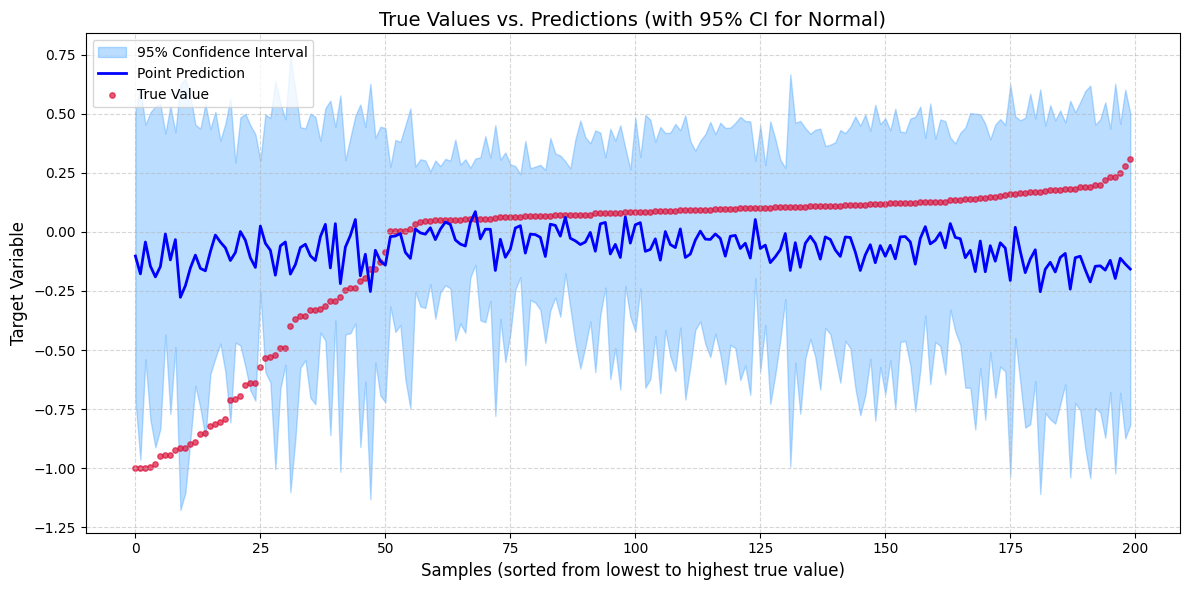

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm, laplace, t

dist_name = best_dist_str

if dist_name == "Normal":
    lower_bound = norm.ppf(0.025, loc=holdout_point, scale=holdout_std)
    upper_bound = norm.ppf(0.975, loc=holdout_point, scale=holdout_std)
elif dist_name == "Laplace":
    lower_bound = laplace.ppf(0.025, loc=holdout_point, scale=holdout_std)
    upper_bound = laplace.ppf(0.975, loc=holdout_point, scale=holdout_std)

sort_idx = np.argsort(y_val_holdout)
y_true_sorted = y_val_holdout[sort_idx]
y_pred_sorted = holdout_point[sort_idx]
lower_sorted = lower_bound[sort_idx]
upper_sorted = upper_bound[sort_idx]

plt.figure(figsize=(12, 6))
plt.fill_between(range(len(y_true_sorted)), lower_sorted, upper_sorted, 
                 color='dodgerblue', alpha=0.3, label='95% Confidence Interval')
plt.plot(range(len(y_true_sorted)), y_pred_sorted, color='blue', linewidth=2, label='Point Prediction')
plt.scatter(range(len(y_true_sorted)), y_true_sorted, color='crimson', s=15, alpha=0.7, label='True Value')
plt.title(f'True Values vs. Predictions (with 95% CI for {dist_name})', fontsize=14)
plt.xlabel('Samples (sorted from lowest to highest true value)', fontsize=12)
plt.ylabel('Target Variable', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

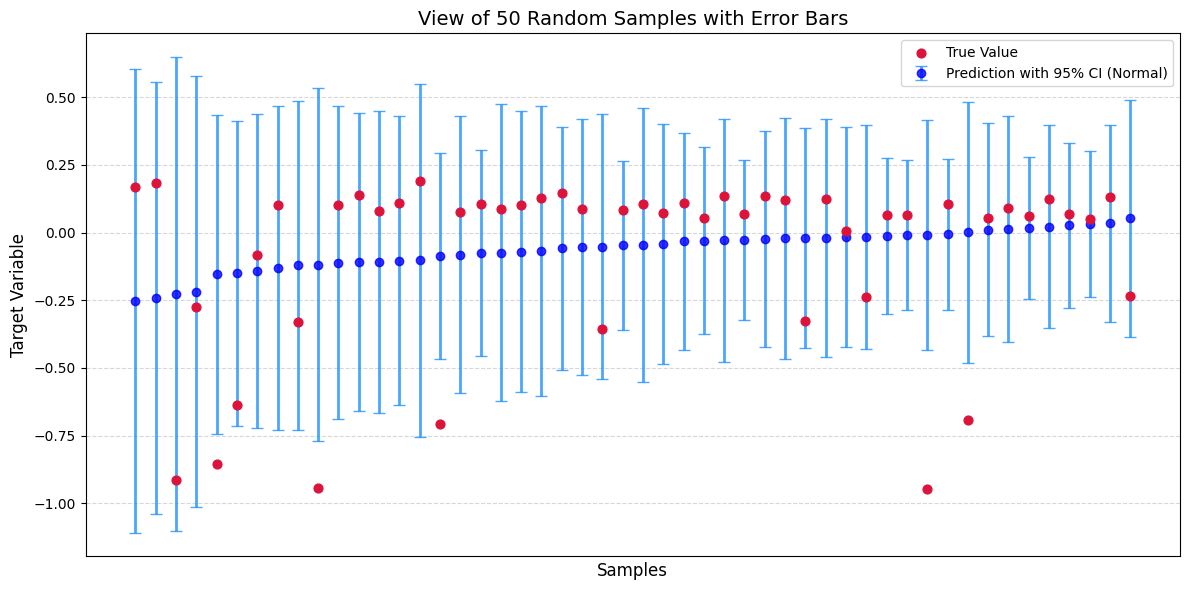

In [9]:
n_samples = 50
sample_idx = np.random.choice(len(y_val_holdout), size=n_samples, replace=False)

y_true_sample = y_val_holdout[sample_idx]
y_pred_sample = holdout_point[sample_idx]
lower_sample = lower_bound[sample_idx]
upper_sample = upper_bound[sample_idx]

sort_idx = np.argsort(y_pred_sample)
y_true_sample = y_true_sample[sort_idx]
y_pred_sample = y_pred_sample[sort_idx]
lower_sample = lower_sample[sort_idx]
upper_sample = upper_sample[sort_idx]

yerr_lower = y_pred_sample - lower_sample
yerr_upper = upper_sample - y_pred_sample

plt.figure(figsize=(12, 6))
plt.errorbar(range(n_samples), y_pred_sample, yerr=[yerr_lower, yerr_upper], 
             fmt='o', color='blue', ecolor='dodgerblue', elinewidth=2, capsize=4, 
             alpha=0.8, label=f'Prediction with 95% CI ({dist_name})')
plt.scatter(range(n_samples), y_true_sample, color='crimson', s=40, zorder=3, label='True Value')
plt.title(f'View of {n_samples} Random Samples with Error Bars', fontsize=14)
plt.xlabel('Samples', fontsize=12)
plt.ylabel('Target Variable', fontsize=12)
plt.xticks([])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 10k

In [ ]:
import optuna
import numpy as np
import warnings
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from optuna.visualization import (
    plot_optimization_history, 
    plot_param_importances, 
    plot_parallel_coordinate
)
from optuna.samplers import TPESampler
from ngboost import NGBRegressor
from ngboost.distns import Normal, Laplace
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import make_pipeline

# Parameter tuning settings

timeout_seconds = 60*60*1
no_improvement_trials = 100

# Split the 10k dataset to evaluate on holdout after tuning

X_tuning = train_10k_X.head(8000)
y_tuning = train_10k_y_reg.head(8000)
X_val_holdout = train_10k_X.tail(2000)
y_val_holdout = train_10k_y_reg.tail(2000)

def objective_ngboost(trial):
    base_params = {
        "criterion": "friedman_mse",
        "max_depth": trial.suggest_int("base_max_depth", 2, 8), # Max tree depth
        "min_samples_split": trial.suggest_int("base_min_samples_split", 15, 100), # Min samples required to split an internal node
        "min_samples_leaf": trial.suggest_int("base_min_samples_leaf", 15, 100), # Min samples required in a leaf node
        "min_weight_fraction_leaf": trial.suggest_float("base_min_weight_fraction_leaf", 0, 0.5), # Min weight fraction required in a leaf node
        "max_features": trial.suggest_categorical("base_max_features", ["sqrt", "log2", None]), # Number of features to consider when looking for the best split
        "ccp_alpha": trial.suggest_float("base_ccp_alpha", 1e-5, 0.1, log=True), # Complexity parameter for Minimal Cost-Complexity Pruning
        "max_leaf_nodes": trial.suggest_int("base_max_leaf_nodes", 3, 31), # Max leaf nodes in the tree
        "min_impurity_decrease": trial.suggest_float("base_min_impurity_decrease", 0, 1.0), # Min impurity decrease required for a split
        "random_state": 42 # For reproducibility
    }
    
    base_learner = DecisionTreeRegressor(**base_params)
    
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000), # Number of boosting rounds,
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True), # Step size
        "minibatch_frac": trial.suggest_float("minibatch_frac", 0.5, 1.0), # Fraction of data to use for fitting each base learner
        "col_sample": trial.suggest_float("col_sample", 0.3, 0.8), # Fraction of features to consider for each base learner
        "random_state": 42, # For reproducibility
        "verbose": False, # No verbose output during training
    }

    # Suggest distribution as a string
    dist_choice = trial.suggest_categorical("Dist", ["Normal", "Laplace"])
    
    # Map the string to the imported class
    dist_mapping = {
        "Normal": Normal, 
        "Laplace": Laplace
    }
    selected_dist = dist_mapping[dist_choice]

    full_pipeline = make_pipeline(
        numeric_preprocessor,
        NGBRegressor(Dist=selected_dist, Base=base_learner, **params)
    )
    
    tscv = TimeSeriesSplit(n_splits=5)
    cv_scores = []
    
    for train_idx, val_idx in tscv.split(X_tuning):
        X_tr, X_val = X_tuning.iloc[train_idx], X_tuning.iloc[val_idx]
        y_tr = y_tuning.iloc[train_idx].values
        y_val = y_tuning.iloc[val_idx].values
        
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                full_pipeline.fit(X_tr, y_tr,)
        except np.linalg.LinAlgError:
            return 0.0
        
        preds = full_pipeline.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        cv_scores.append(rmse)
        
    return np.mean(cv_scores)

def stop_optuna(study, trial): # Custom callback to stop optimization if no improvement in best RMSE for a certain number of trials
    if study.best_trial.number + no_improvement_trials <= trial.number:
        print(f"\n[Early Stop] No improvement in {no_improvement_trials} trials. Stopping optimization.")
        study.stop()

study_ngboost = optuna.create_study(direction="minimize", sampler=TPESampler(seed=42))
study_ngboost.optimize(objective_ngboost, timeout=timeout_seconds, n_jobs=-1, callbacks=[stop_optuna])

print("\n" + "="*40)
print(f"BEST RMSE: {study_ngboost.best_value:.4f}")
print("BEST PARAMETERS:")

print("best_params = {")
for k, v in study_ngboost.best_params.items():
    if isinstance(v, str):
        print(f'    "{k}": "{v}",')
    else:
        print(f'    "{k}": {v},')
print("}")

print("\n--- PARAMETER IMPORTANCE ---")
importances = optuna.importance.get_param_importances(study_ngboost)
for param, importance in importances.items():
    print(f"  {param:20}: {importance:.4f}")
print("="*40)


fig1 = plot_optimization_history(study_ngboost)
fig1.show()
    
fig2 = plot_param_importances(study_ngboost)
fig2.show()
    
fig3 = plot_parallel_coordinate(study_ngboost)
fig3.show()
    
fig1.write_html("hyperparameter_tuning/NGBoost/Regression/optuna_ngboost_10k_history.html")
fig2.write_html("hyperparameter_tuning/NGBoost/Regression/optuna_ngboost_10k_importance.html")
fig3.write_html("hyperparameter_tuning/NGBoost/Regression/optuna_ngboost_10k_parallel.html")


[I 2026-04-26 14:56:55,543] A new study created in memory with name: no-name-0306cac0-0209-4e09-83ab-9c206b111d3c
[I 2026-04-26 14:57:53,162] Trial 3 finished with value: 0.29790367520173117 and parameters: {'base_max_depth': 4, 'base_min_samples_split': 74, 'base_min_samples_leaf': 26, 'base_min_weight_fraction_leaf': 0.047106823491502026, 'base_max_features': 'sqrt', 'base_ccp_alpha': 0.00012278386422537847, 'base_max_leaf_nodes': 14, 'base_min_impurity_decrease': 0.7748632727850571, 'n_estimators': 222, 'learning_rate': 0.10977218542315906, 'minibatch_frac': 0.8850810425462461, 'col_sample': 0.3428234434984991, 'Dist': 'Normal'}. Best is trial 3 with value: 0.29790367520173117.
[I 2026-04-26 14:58:00,888] Trial 7 finished with value: 0.3212502798384557 and parameters: {'base_max_depth': 2, 'base_min_samples_split': 45, 'base_min_samples_leaf': 58, 'base_min_weight_fraction_leaf': 0.11072076148742765, 'base_max_features': 'sqrt', 'base_ccp_alpha': 0.09112224974885973, 'base_max_leaf_


[Early Stop] No improvement in 100 trials. Stopping optimization.


[I 2026-04-26 15:45:32,096] Trial 126 finished with value: 0.2995005340249176 and parameters: {'base_max_depth': 8, 'base_min_samples_split': 45, 'base_min_samples_leaf': 44, 'base_min_weight_fraction_leaf': 0.015154655514940092, 'base_max_features': None, 'base_ccp_alpha': 0.0006590972652424751, 'base_max_leaf_nodes': 9, 'base_min_impurity_decrease': 0.4399542811881628, 'n_estimators': 754, 'learning_rate': 0.01740251642307955, 'minibatch_frac': 0.8094682038298125, 'col_sample': 0.7846087221713912, 'Dist': 'Normal'}. Best is trial 35 with value: 0.29695551557725314.
[I 2026-04-26 15:46:19,319] Trial 136 finished with value: 0.29744970291836 and parameters: {'base_max_depth': 8, 'base_min_samples_split': 39, 'base_min_samples_leaf': 35, 'base_min_weight_fraction_leaf': 0.09167351628139857, 'base_max_features': 'log2', 'base_ccp_alpha': 1.3847384884708261e-05, 'base_max_leaf_nodes': 11, 'base_min_impurity_decrease': 0.4830331623572925, 'n_estimators': 765, 'learning_rate': 0.01642683275


[Early Stop] No improvement in 100 trials. Stopping optimization.


[I 2026-04-26 15:46:36,015] Trial 137 finished with value: 0.2977934684933173 and parameters: {'base_max_depth': 8, 'base_min_samples_split': 56, 'base_min_samples_leaf': 35, 'base_min_weight_fraction_leaf': 0.0936394191449462, 'base_max_features': 'log2', 'base_ccp_alpha': 1.743614080068499e-05, 'base_max_leaf_nodes': 17, 'base_min_impurity_decrease': 0.36425381310868976, 'n_estimators': 775, 'learning_rate': 0.022969326735586423, 'minibatch_frac': 0.5421647958886651, 'col_sample': 0.7251195853423349, 'Dist': 'Normal'}. Best is trial 35 with value: 0.29695551557725314.


...


[Early Stop] No improvement in 100 trials. Stopping optimization.


[I 2026-04-26 15:46:46,324] Trial 139 finished with value: 0.30058258488074846 and parameters: {'base_max_depth': 8, 'base_min_samples_split': 38, 'base_min_samples_leaf': 41, 'base_min_weight_fraction_leaf': 0.005023254371916931, 'base_max_features': 'log2', 'base_ccp_alpha': 0.08522579472360997, 'base_max_leaf_nodes': 17, 'base_min_impurity_decrease': 0.35960818859331056, 'n_estimators': 701, 'learning_rate': 0.015263857534112081, 'minibatch_frac': 0.5565215179963959, 'col_sample': 0.7293491885006906, 'Dist': 'Normal'}. Best is trial 35 with value: 0.29695551557725314.



[Early Stop] No improvement in 100 trials. Stopping optimization.


[I 2026-04-26 15:46:49,501] Trial 140 finished with value: 0.2968008923280196 and parameters: {'base_max_depth': 8, 'base_min_samples_split': 38, 'base_min_samples_leaf': 41, 'base_min_weight_fraction_leaf': 0.0003213921303004477, 'base_max_features': 'log2', 'base_ccp_alpha': 1.8549133165544335e-05, 'base_max_leaf_nodes': 17, 'base_min_impurity_decrease': 0.38252906628451194, 'n_estimators': 714, 'learning_rate': 0.011486310063486665, 'minibatch_frac': 0.5442236810583654, 'col_sample': 0.7169685029737407, 'Dist': 'Normal'}. Best is trial 140 with value: 0.2968008923280196.
[I 2026-04-26 15:47:33,954] Trial 133 finished with value: 0.2990700398335759 and parameters: {'base_max_depth': 8, 'base_min_samples_split': 56, 'base_min_samples_leaf': 41, 'base_min_weight_fraction_leaf': 0.012794757633910745, 'base_max_features': None, 'base_ccp_alpha': 0.0006778926618524738, 'base_max_leaf_nodes': 11, 'base_min_impurity_decrease': 0.38728962065349193, 'n_estimators': 752, 'learning_rate': 0.016


BEST RMSE: 0.2968
BEST PARAMETERS:
best_params = {
    "base_max_depth": 8,
    "base_min_samples_split": 38,
    "base_min_samples_leaf": 41,
    "base_min_weight_fraction_leaf": 0.0003213921303004477,
    "base_max_features": "log2",
    "base_ccp_alpha": 1.8549133165544335e-05,
    "base_max_leaf_nodes": 17,
    "base_min_impurity_decrease": 0.38252906628451194,
    "n_estimators": 714,
    "learning_rate": 0.011486310063486665,
    "minibatch_frac": 0.5442236810583654,
    "col_sample": 0.7169685029737407,
    "Dist": "Normal",
}

--- PARAMETER IMPORTANCE ---
  Dist                : 0.9907
  learning_rate       : 0.0016
  col_sample          : 0.0015
  base_min_impurity_decrease: 0.0011
  base_max_leaf_nodes : 0.0010
  base_max_features   : 0.0010
  minibatch_frac      : 0.0009
  base_min_samples_split: 0.0008
  n_estimators        : 0.0004
  base_min_weight_fraction_leaf: 0.0004
  base_min_samples_leaf: 0.0003
  base_ccp_alpha      : 0.0002
  base_max_depth      : 0.0001


In [11]:
best_params = study_ngboost.best_params.copy()

best_dist_str = best_params.pop("Dist")
dist_mapping = {
    "Normal": Normal, 
    "Laplace": Laplace
}
best_dist = dist_mapping[best_dist_str]

base_params = {
    "criterion": "friedman_mse",
    "max_depth": best_params.pop("base_max_depth"),
    "min_samples_split": best_params.pop("base_min_samples_split"),
    "min_samples_leaf": best_params.pop("base_min_samples_leaf"),
    "min_weight_fraction_leaf": best_params.pop("base_min_weight_fraction_leaf"),
    "max_features": best_params.pop("base_max_features"),
    "ccp_alpha": best_params.pop("base_ccp_alpha"),
    "max_leaf_nodes": best_params.pop("base_max_leaf_nodes"),
    "min_impurity_decrease": best_params.pop("base_min_impurity_decrease"),
    "random_state": 42
}

base_learner = DecisionTreeRegressor(**base_params)

best_params["random_state"] = 42
best_params["verbose"] = False
best_params["n_estimators"] = int(best_params["n_estimators"] * 2)
best_params["learning_rate"] = best_params["learning_rate"] / 2
print(f"BEST DIST: {best_dist_str}")
print(f"BASE PARAMS: {base_params}")
print(f"BEST PARAMS: {best_params}")

y_tuning = y_tuning.values
y_val_holdout = y_val_holdout.values

final_pipeline = make_pipeline(
    numeric_preprocessor,
    NGBRegressor(Dist=best_dist, Base=base_learner, **best_params)
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    final_pipeline.fit(X_tuning, y_tuning)

X_val_transformed = final_pipeline[:-1].transform(X_val_holdout)
holdout_dist = final_pipeline.named_steps['ngbregressor'].pred_dist(X_val_transformed)
holdout_point = holdout_dist.loc
holdout_std = holdout_dist.scale

holdout_rmse = np.sqrt(mean_squared_error(y_val_holdout, holdout_point))

print("\n" + "="*40)
print(f"Optuna Val RMSE:   {study_ngboost.best_value:.4f}")
print(f"Holdout Test RMSE: {holdout_rmse:.4f}")
print("="*40)

BEST DIST: Normal
BASE PARAMS: {'criterion': 'friedman_mse', 'max_depth': 8, 'min_samples_split': 38, 'min_samples_leaf': 41, 'min_weight_fraction_leaf': 0.0003213921303004477, 'max_features': 'log2', 'ccp_alpha': 1.8549133165544335e-05, 'max_leaf_nodes': 17, 'min_impurity_decrease': 0.38252906628451194, 'random_state': 42}
BEST PARAMS: {'n_estimators': 1428, 'learning_rate': 0.005743155031743333, 'minibatch_frac': 0.5442236810583654, 'col_sample': 0.7169685029737407, 'random_state': 42, 'verbose': False}

Optuna Val RMSE:   0.2968
Holdout Test RMSE: 0.3117


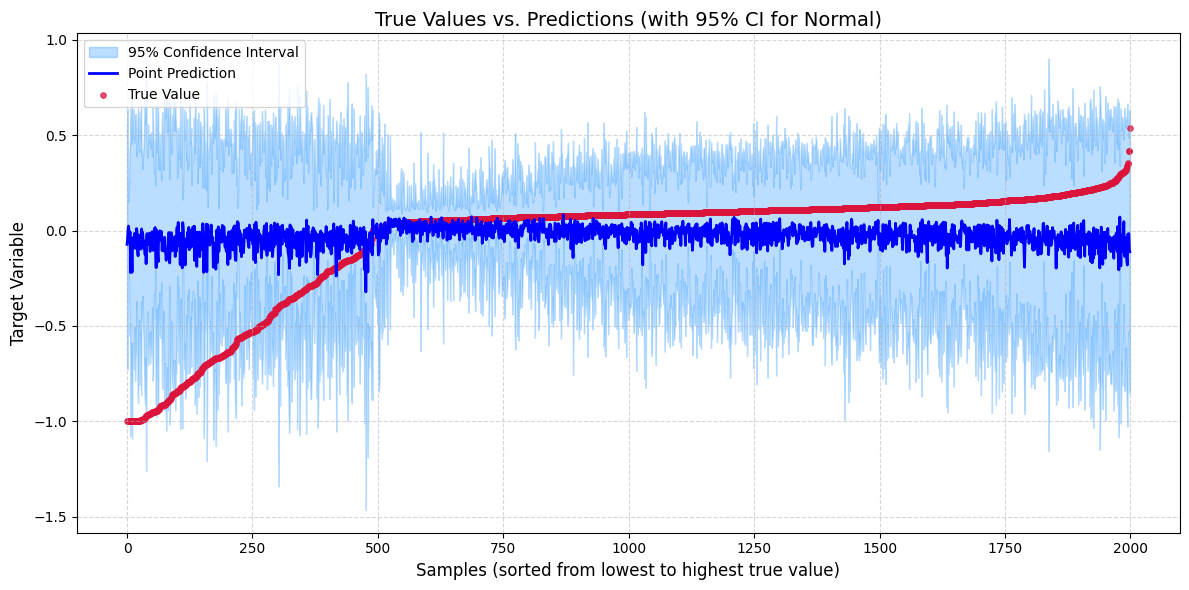

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm, laplace, t

dist_name = best_dist_str

if dist_name == "Normal":
    lower_bound = norm.ppf(0.025, loc=holdout_point, scale=holdout_std)
    upper_bound = norm.ppf(0.975, loc=holdout_point, scale=holdout_std)
elif dist_name == "Laplace":
    lower_bound = laplace.ppf(0.025, loc=holdout_point, scale=holdout_std)
    upper_bound = laplace.ppf(0.975, loc=holdout_point, scale=holdout_std)

sort_idx = np.argsort(y_val_holdout)
y_true_sorted = y_val_holdout[sort_idx]
y_pred_sorted = holdout_point[sort_idx]
lower_sorted = lower_bound[sort_idx]
upper_sorted = upper_bound[sort_idx]

plt.figure(figsize=(12, 6))
plt.fill_between(range(len(y_true_sorted)), lower_sorted, upper_sorted, 
                 color='dodgerblue', alpha=0.3, label='95% Confidence Interval')
plt.plot(range(len(y_true_sorted)), y_pred_sorted, color='blue', linewidth=2, label='Point Prediction')
plt.scatter(range(len(y_true_sorted)), y_true_sorted, color='crimson', s=15, alpha=0.7, label='True Value')
plt.title(f'True Values vs. Predictions (with 95% CI for {dist_name})', fontsize=14)
plt.xlabel('Samples (sorted from lowest to highest true value)', fontsize=12)
plt.ylabel('Target Variable', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

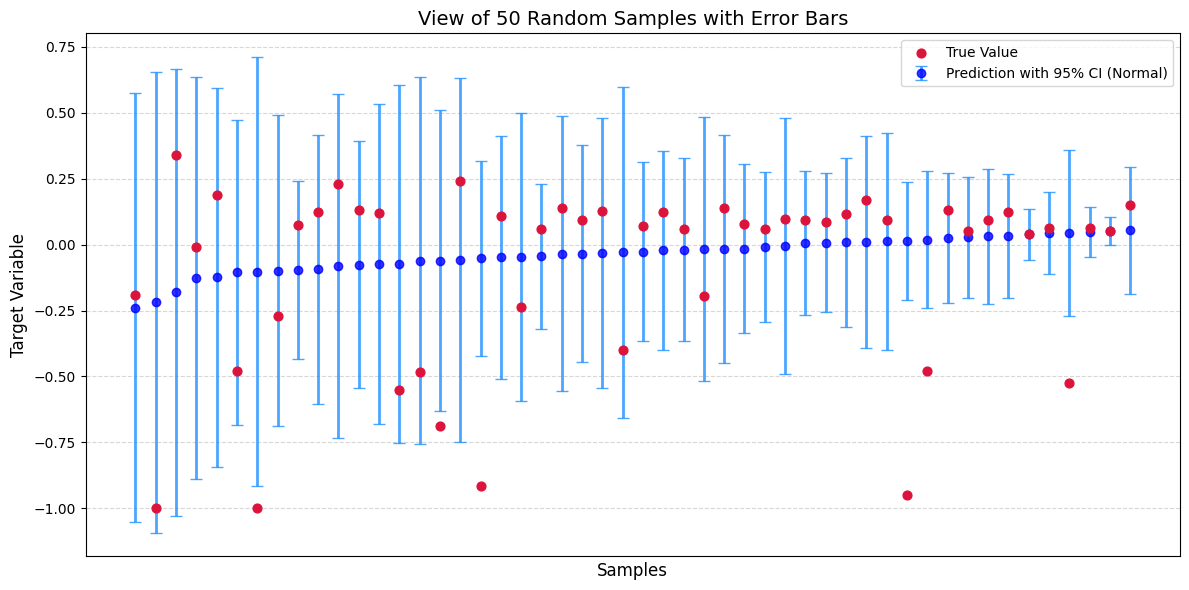

In [13]:
n_samples = 50
sample_idx = np.random.choice(len(y_val_holdout), size=n_samples, replace=False)

y_true_sample = y_val_holdout[sample_idx]
y_pred_sample = holdout_point[sample_idx]
lower_sample = lower_bound[sample_idx]
upper_sample = upper_bound[sample_idx]

sort_idx = np.argsort(y_pred_sample)
y_true_sample = y_true_sample[sort_idx]
y_pred_sample = y_pred_sample[sort_idx]
lower_sample = lower_sample[sort_idx]
upper_sample = upper_sample[sort_idx]

yerr_lower = y_pred_sample - lower_sample
yerr_upper = upper_sample - y_pred_sample

plt.figure(figsize=(12, 6))
plt.errorbar(range(n_samples), y_pred_sample, yerr=[yerr_lower, yerr_upper], 
             fmt='o', color='blue', ecolor='dodgerblue', elinewidth=2, capsize=4, 
             alpha=0.8, label=f'Prediction with 95% CI ({dist_name})')
plt.scatter(range(n_samples), y_true_sample, color='crimson', s=40, zorder=3, label='True Value')
plt.title(f'View of {n_samples} Random Samples with Error Bars', fontsize=14)
plt.xlabel('Samples', fontsize=12)
plt.ylabel('Target Variable', fontsize=12)
plt.xticks([])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 100k

In [ ]:
import optuna
import numpy as np
import warnings
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from optuna.visualization import (
    plot_optimization_history, 
    plot_param_importances, 
    plot_parallel_coordinate
)
from optuna.samplers import TPESampler
from ngboost import NGBRegressor
from ngboost.distns import Normal, Laplace
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import make_pipeline

# Parameter tuning settings

timeout_seconds = 60*60*3
no_improvement_trials = 100

# Split the 100k dataset to evaluate on holdout after tuning

X_tuning = train_100k_X.head(80000)
y_tuning = train_100k_y_reg.head(80000)
X_val_holdout = train_100k_X.tail(20000)
y_val_holdout = train_100k_y_reg.tail(20000)

def objective_ngboost(trial):
    base_params = {
        "criterion": "friedman_mse",
        "max_depth": trial.suggest_int("base_max_depth", 2, 20), # Max tree depth
        "min_samples_split": trial.suggest_int("base_min_samples_split", 10, 500), # Min samples required to split an internal node
        "min_samples_leaf": trial.suggest_int("base_min_samples_leaf", 10, 500), # Min samples required in a leaf node
        "min_weight_fraction_leaf": trial.suggest_float("base_min_weight_fraction_leaf", 0, 0.5), # Min weight fraction required in a leaf node
        "max_features": trial.suggest_categorical("base_max_features", ["sqrt", "log2", None]), # Number of features to consider when looking for the best split
        "ccp_alpha": trial.suggest_float("base_ccp_alpha", 1e-5, 0.1, log=True), # Complexity parameter for Minimal Cost-Complexity Pruning
        "max_leaf_nodes": trial.suggest_int("base_max_leaf_nodes", 5, 512), # Max leaf nodes in the tree
        "min_impurity_decrease": trial.suggest_float("base_min_impurity_decrease", 0, 1.0), # Min impurity decrease required for a split
        "random_state": 42 # For reproducibility
    }
    
    base_learner = DecisionTreeRegressor(**base_params)
    
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000), # Number of boosting rounds,
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True), # Step size
        "minibatch_frac": trial.suggest_float("minibatch_frac", 0.5, 1.0), # Fraction of data to use for fitting each base learner
        "col_sample": trial.suggest_float("col_sample", 0.3, 1.0), # Fraction of features to consider for each base learner
        "random_state": 42, # For reproducibility
        "verbose": False, # No verbose output during training
    }

    # Suggest distribution as a string
    dist_choice = trial.suggest_categorical("Dist", ["Normal", "Laplace"])
    
    # Map the string to the imported class
    dist_mapping = {
        "Normal": Normal, 
        "Laplace": Laplace
    }
    selected_dist = dist_mapping[dist_choice]

    full_pipeline = make_pipeline(
        numeric_preprocessor,
        NGBRegressor(Dist=selected_dist, Base=base_learner, **params)
    )
    
    tscv = TimeSeriesSplit(n_splits=5)
    cv_scores = []
    
    for train_idx, val_idx in tscv.split(X_tuning):
        X_tr, X_val = X_tuning.iloc[train_idx], X_tuning.iloc[val_idx]
        y_tr = y_tuning.iloc[train_idx].values
        y_val = y_tuning.iloc[val_idx].values
        
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                full_pipeline.fit(X_tr, y_tr,)
        except np.linalg.LinAlgError:
            return 0.0
        
        preds = full_pipeline.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        cv_scores.append(rmse)
        
    return np.mean(cv_scores)

def stop_optuna(study, trial): # Custom callback to stop optimization if no improvement in best RMSE for a certain number of trials
    if study.best_trial.number + no_improvement_trials <= trial.number:
        print(f"\n[Early Stop] No improvement in {no_improvement_trials} trials. Stopping optimization.")
        study.stop()

study_ngboost = optuna.create_study(direction="minimize", sampler=TPESampler(seed=42))
study_ngboost.optimize(objective_ngboost, timeout=timeout_seconds, n_jobs=-1, callbacks=[stop_optuna])

print("\n" + "="*40)
print(f"BEST RMSE: {study_ngboost.best_value:.4f}")
print("BEST PARAMETERS:")

print("best_params = {")
for k, v in study_ngboost.best_params.items():
    if isinstance(v, str):
        print(f'    "{k}": "{v}",')
    else:
        print(f'    "{k}": {v},')
print("}")

print("\n--- PARAMETER IMPORTANCE ---")
importances = optuna.importance.get_param_importances(study_ngboost)
for param, importance in importances.items():
    print(f"  {param:20}: {importance:.4f}")
print("="*40)


fig1 = plot_optimization_history(study_ngboost)
fig1.show()
    
fig2 = plot_param_importances(study_ngboost)
fig2.show()
    
fig3 = plot_parallel_coordinate(study_ngboost)
fig3.show()
    
fig1.write_html("hyperparameter_tuning/NGBoost/Regression/optuna_ngboost_100k_history.html")
fig2.write_html("hyperparameter_tuning/NGBoost/Regression/optuna_ngboost_100k_importance.html")
fig3.write_html("hyperparameter_tuning/NGBoost/Regression/optuna_ngboost_100k_parallel.html")


[I 2026-04-26 10:26:51,234] A new study created in memory with name: no-name-aa90b29e-a8e8-4516-bc18-57e76023b0fe
[I 2026-04-26 10:27:51,670] Trial 0 finished with value: 0.3085389717911731 and parameters: {'base_max_depth': 9, 'base_min_samples_split': 387, 'base_min_samples_leaf': 417, 'base_min_weight_fraction_leaf': 0.29480465210945106, 'base_max_features': 'log2', 'base_ccp_alpha': 0.07196803783402328, 'base_max_leaf_nodes': 389, 'base_min_impurity_decrease': 0.5906990917030795, 'n_estimators': 170, 'learning_rate': 0.14506884110770907, 'minibatch_frac': 0.9204469591020764, 'col_sample': 0.5985894741757924, 'Dist': 'Normal'}. Best is trial 0 with value: 0.3085389717911731.
[I 2026-04-26 10:28:04,936] Trial 2 finished with value: 0.3308522328859796 and parameters: {'base_max_depth': 5, 'base_min_samples_split': 66, 'base_min_samples_leaf': 40, 'base_min_weight_fraction_leaf': 0.3082518212556026, 'base_max_features': 'sqrt', 'base_ccp_alpha': 0.0010474915901119639, 'base_max_leaf_no


BEST RMSE: 0.2996
BEST PARAMETERS:
best_params = {
    "base_max_depth": 17,
    "base_min_samples_split": 35,
    "base_min_samples_leaf": 371,
    "base_min_weight_fraction_leaf": 0.003373989905557241,
    "base_max_features": "sqrt",
    "base_ccp_alpha": 2.1975874211460698e-05,
    "base_max_leaf_nodes": 30,
    "base_min_impurity_decrease": 0.035785241864927805,
    "n_estimators": 354,
    "learning_rate": 0.031005975042584923,
    "minibatch_frac": 0.5337656312465495,
    "col_sample": 0.7957079748440611,
    "Dist": "Normal",
}

--- PARAMETER IMPORTANCE ---
  Dist                : 0.9735
  learning_rate       : 0.0089
  base_max_depth      : 0.0087
  n_estimators        : 0.0024
  base_min_samples_split: 0.0012
  base_min_weight_fraction_leaf: 0.0011
  base_max_features   : 0.0009
  col_sample          : 0.0009
  minibatch_frac      : 0.0007
  base_min_samples_leaf: 0.0005
  base_ccp_alpha      : 0.0004
  base_min_impurity_decrease: 0.0004
  base_max_leaf_nodes : 0.0004


In [18]:
best_params = study_ngboost.best_params.copy()

best_dist_str = best_params.pop("Dist")
dist_mapping = {
    "Normal": Normal, 
    "Laplace": Laplace
}
best_dist = dist_mapping[best_dist_str]

base_params = {
    "criterion": "friedman_mse",
    "max_depth": best_params.pop("base_max_depth"),
    "min_samples_split": best_params.pop("base_min_samples_split"),
    "min_samples_leaf": best_params.pop("base_min_samples_leaf"),
    "min_weight_fraction_leaf": best_params.pop("base_min_weight_fraction_leaf"),
    "max_features": best_params.pop("base_max_features"),
    "ccp_alpha": best_params.pop("base_ccp_alpha"),
    "max_leaf_nodes": best_params.pop("base_max_leaf_nodes"),
    "min_impurity_decrease": best_params.pop("base_min_impurity_decrease"),
    "random_state": 42
}

base_learner = DecisionTreeRegressor(**base_params)

best_params["random_state"] = 42
best_params["verbose"] = False
best_params["n_estimators"] = int(best_params["n_estimators"] * 10)
best_params["learning_rate"] = best_params["learning_rate"] / 10
print(f"BEST DIST: {best_dist_str}")
print(f"BASE PARAMS: {base_params}")
print(f"BEST PARAMS: {best_params}")

y_tuning = y_tuning.values
y_val_holdout = y_val_holdout.values

final_pipeline = make_pipeline(
    numeric_preprocessor,
    NGBRegressor(Dist=best_dist, Base=base_learner, **best_params)
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    final_pipeline.fit(X_tuning, y_tuning)

X_val_transformed = final_pipeline[:-1].transform(X_val_holdout)
holdout_dist = final_pipeline.named_steps['ngbregressor'].pred_dist(X_val_transformed)
holdout_point = holdout_dist.loc
holdout_std = holdout_dist.scale

holdout_rmse = np.sqrt(mean_squared_error(y_val_holdout, holdout_point))

print("\n" + "="*40)
print(f"Optuna Val RMSE:   {study_ngboost.best_value:.4f}")
print(f"Holdout Test RMSE: {holdout_rmse:.4f}")
print("="*40)

BEST DIST: Normal
BASE PARAMS: {'criterion': 'friedman_mse', 'max_depth': 17, 'min_samples_split': 35, 'min_samples_leaf': 371, 'min_weight_fraction_leaf': 0.003373989905557241, 'max_features': 'sqrt', 'ccp_alpha': 2.1975874211460698e-05, 'max_leaf_nodes': 30, 'min_impurity_decrease': 0.035785241864927805, 'random_state': 42}
BEST PARAMS: {'n_estimators': 3540, 'learning_rate': 0.0031005975042584922, 'minibatch_frac': 0.5337656312465495, 'col_sample': 0.7957079748440611, 'random_state': 42, 'verbose': False}

Optuna Val RMSE:   0.2996
Holdout Test RMSE: 0.2986


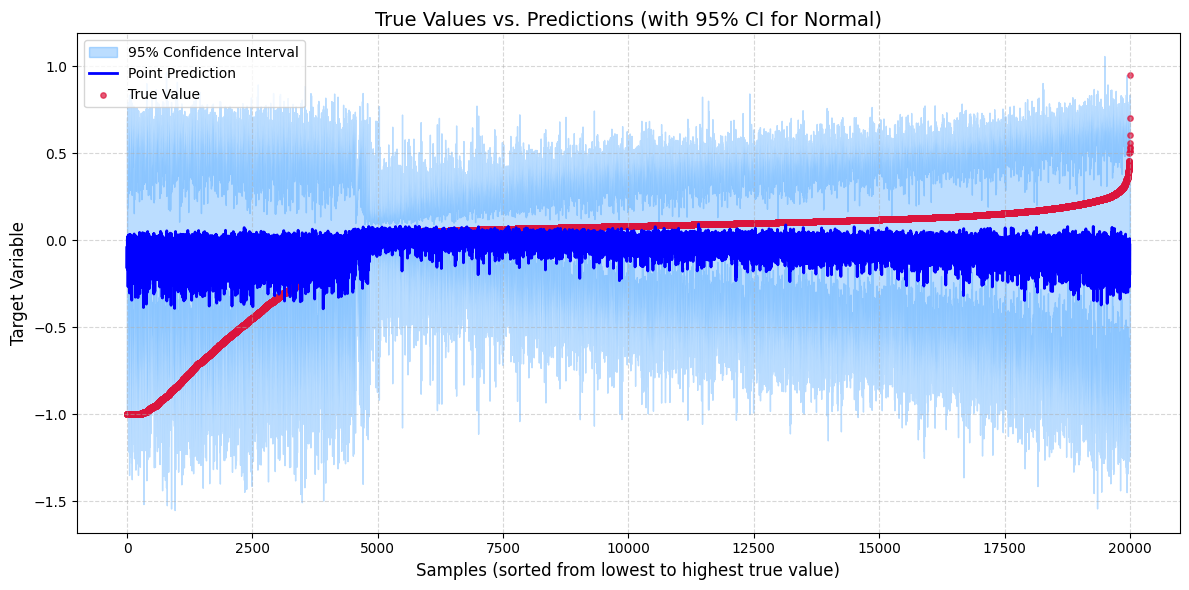

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm, laplace, t

dist_name = best_dist_str

if dist_name == "Normal":
    lower_bound = norm.ppf(0.025, loc=holdout_point, scale=holdout_std)
    upper_bound = norm.ppf(0.975, loc=holdout_point, scale=holdout_std)
elif dist_name == "Laplace":
    lower_bound = laplace.ppf(0.025, loc=holdout_point, scale=holdout_std)
    upper_bound = laplace.ppf(0.975, loc=holdout_point, scale=holdout_std)

sort_idx = np.argsort(y_val_holdout)
y_true_sorted = y_val_holdout[sort_idx]
y_pred_sorted = holdout_point[sort_idx]
lower_sorted = lower_bound[sort_idx]
upper_sorted = upper_bound[sort_idx]

plt.figure(figsize=(12, 6))
plt.fill_between(range(len(y_true_sorted)), lower_sorted, upper_sorted, 
                 color='dodgerblue', alpha=0.3, label='95% Confidence Interval')
plt.plot(range(len(y_true_sorted)), y_pred_sorted, color='blue', linewidth=2, label='Point Prediction')
plt.scatter(range(len(y_true_sorted)), y_true_sorted, color='crimson', s=15, alpha=0.7, label='True Value')
plt.title(f'True Values vs. Predictions (with 95% CI for {dist_name})', fontsize=14)
plt.xlabel('Samples (sorted from lowest to highest true value)', fontsize=12)
plt.ylabel('Target Variable', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

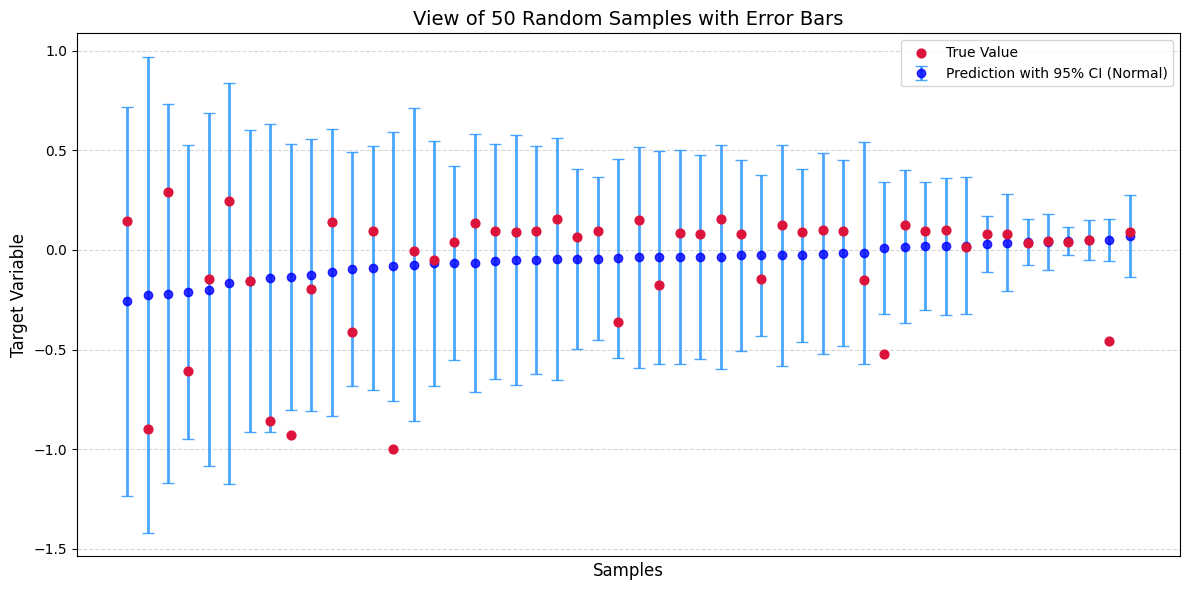

In [20]:
n_samples = 50
sample_idx = np.random.choice(len(y_val_holdout), size=n_samples, replace=False)

y_true_sample = y_val_holdout[sample_idx]
y_pred_sample = holdout_point[sample_idx]
lower_sample = lower_bound[sample_idx]
upper_sample = upper_bound[sample_idx]

sort_idx = np.argsort(y_pred_sample)
y_true_sample = y_true_sample[sort_idx]
y_pred_sample = y_pred_sample[sort_idx]
lower_sample = lower_sample[sort_idx]
upper_sample = upper_sample[sort_idx]

yerr_lower = y_pred_sample - lower_sample
yerr_upper = upper_sample - y_pred_sample

plt.figure(figsize=(12, 6))
plt.errorbar(range(n_samples), y_pred_sample, yerr=[yerr_lower, yerr_upper], 
             fmt='o', color='blue', ecolor='dodgerblue', elinewidth=2, capsize=4, 
             alpha=0.8, label=f'Prediction with 95% CI ({dist_name})')
plt.scatter(range(n_samples), y_true_sample, color='crimson', s=40, zorder=3, label='True Value')
plt.title(f'View of {n_samples} Random Samples with Error Bars', fontsize=14)
plt.xlabel('Samples', fontsize=12)
plt.ylabel('Target Variable', fontsize=12)
plt.xticks([])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Whole training data set

In [ ]:
import optuna
import numpy as np
import warnings
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from optuna.visualization import (
    plot_optimization_history, 
    plot_param_importances, 
    plot_parallel_coordinate
)
from optuna.samplers import TPESampler
from ngboost import NGBRegressor
from ngboost.distns import Normal, Laplace
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import make_pipeline


# Parameter tuning settings

timeout_seconds = 60*60*4
no_improvement_trials = 100

# Split the 100k dataset to evaluate on holdout after tuning

split_index = int(len(train_full_X) * 0.8)

X_tuning = train_full_X[:split_index]
y_tuning = train_full_y_reg[:split_index]
X_val_holdout = train_full_X[split_index:]
y_val_holdout = train_full_y_reg[split_index:]

def objective_ngboost(trial):
    base_params = {
        "criterion": "friedman_mse",
        "max_depth": trial.suggest_int("base_max_depth", 2, 20), # Max tree depth
        "min_samples_split": trial.suggest_int("base_min_samples_split", 10, 500), # Min samples required to split an internal node
        "min_samples_leaf": trial.suggest_int("base_min_samples_leaf", 10, 500), # Min samples required in a leaf node
        "min_weight_fraction_leaf": trial.suggest_float("base_min_weight_fraction_leaf", 0, 0.5), # Min weight fraction required in a leaf node
        "max_features": trial.suggest_categorical("base_max_features", ["sqrt", "log2", None]), # Number of features to consider when looking for the best split
        "ccp_alpha": trial.suggest_float("base_ccp_alpha", 1e-5, 0.1, log=True), # Complexity parameter for Minimal Cost-Complexity Pruning
        "max_leaf_nodes": trial.suggest_int("base_max_leaf_nodes", 5, 512), # Max leaf nodes in the tree
        "min_impurity_decrease": trial.suggest_float("base_min_impurity_decrease", 0, 1.0), # Min impurity decrease required for a split
        "random_state": 42 # For reproducibility
    }
    
    base_learner = DecisionTreeRegressor(**base_params)
    
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000), # Number of boosting rounds,
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True), # Step size
        "minibatch_frac": trial.suggest_float("minibatch_frac", 0.5, 1.0), # Fraction of data to use for fitting each base learner
        "col_sample": trial.suggest_float("col_sample", 0.3, 1.0), # Fraction of features to consider for each base learner
        "random_state": 42, # For reproducibility
        "verbose": False, # No verbose output during training
    }

    # Suggest distribution as a string
    dist_choice = trial.suggest_categorical("Dist", ["Normal", "Laplace"])
    
    # Map the string to the imported class
    dist_mapping = {
        "Normal": Normal, 
        "Laplace": Laplace
    }
    selected_dist = dist_mapping[dist_choice]

    full_pipeline = make_pipeline(
        numeric_preprocessor,
        NGBRegressor(Dist=selected_dist, Base=base_learner, **params)
    )
    
    tscv = TimeSeriesSplit(n_splits=3)
    cv_scores = []
    
    for train_idx, val_idx in tscv.split(X_tuning):
        X_tr, X_val = X_tuning.iloc[train_idx], X_tuning.iloc[val_idx]
        y_tr = y_tuning.iloc[train_idx].values
        y_val = y_tuning.iloc[val_idx].values
        
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                full_pipeline.fit(X_tr, y_tr,)
        except np.linalg.LinAlgError:
            return 0.0
        
        preds = full_pipeline.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        cv_scores.append(rmse)
        
    return np.mean(cv_scores)

def stop_optuna(study, trial): # Custom callback to stop optimization if no improvement in best RMSE for a certain number of trials
    if study.best_trial.number + no_improvement_trials <= trial.number:
        print(f"\n[Early Stop] No improvement in {no_improvement_trials} trials. Stopping optimization.")
        study.stop()

study_ngboost = optuna.create_study(direction="minimize", sampler=TPESampler(seed=42))
study_ngboost.optimize(objective_ngboost, timeout=timeout_seconds, n_jobs=-1, callbacks=[stop_optuna])

print("\n" + "="*40)
print(f"BEST RMSE: {study_ngboost.best_value:.4f}")
print("BEST PARAMETERS:")

print("best_params = {")
for k, v in study_ngboost.best_params.items():
    if isinstance(v, str):
        print(f'    "{k}": "{v}",')
    else:
        print(f'    "{k}": {v},')
print("}")

print("\n--- PARAMETER IMPORTANCE ---")
importances = optuna.importance.get_param_importances(study_ngboost)
for param, importance in importances.items():
    print(f"  {param:20}: {importance:.4f}")
print("="*40)


fig1 = plot_optimization_history(study_ngboost)
fig1.show()
    
fig2 = plot_param_importances(study_ngboost)
fig2.show()
    
fig3 = plot_parallel_coordinate(study_ngboost)
fig3.show()
    
fig1.write_html("hyperparameter_tuning/NGBoost/Regression/optuna_ngboost_full_history.html")
fig2.write_html("hyperparameter_tuning/NGBoost/Regression/optuna_ngboost_full_importance.html")
fig3.write_html("hyperparameter_tuning/NGBoost/Regression/optuna_ngboost_full_parallel.html")


[I 2026-04-22 00:55:36,440] A new study created in memory with name: no-name-e6e86f3f-4af6-4c6c-bb30-bebed2ab97f3
[I 2026-04-22 00:56:27,391] Trial 3 finished with value: 0.7509030339384353 and parameters: {'boosting_type': 'goss', 'num_leaves': 377, 'max_depth': 2, 'learning_rate': 0.1903428179678173, 'scale_pos_weight': 6.082125486473243, 'min_split_gain': 26.39142477642419, 'min_child_weight': 4.8185524092618045e-05, 'min_child_samples': 290, 'colsample_bytree': 0.5066837006445346, 'reg_alpha': 0.008590451603378712, 'reg_lambda': 0.0006321751034820287, 'colsample_bynode': 0.6989172440719156, 'min_data_per_group': 976, 'max_cat_threshold': 632, 'cat_l2': 4.676533112163103e-06, 'cat_smooth': 34.70861426629406, 'max_cat_to_onehot': 37, 'max_bin': 433, 'top_rate': 0.7237115739628408, 'other_rate': 0.1719406111579936, 'n_estimators': 6050}. Best is trial 3 with value: 0.7509030339384353.
[I 2026-04-22 00:56:59,196] Trial 6 finished with value: 0.7442250170611076 and parameters: {'boostin


BEST AUC: 0.7566
BEST PARAMETERS:
best_params = {
    "boosting_type": "goss",
    "num_leaves": 298,
    "max_depth": 20,
    "learning_rate": 0.002488325776616227,
    "scale_pos_weight": 5.888271675991455,
    "min_split_gain": 1.6197064284930547,
    "min_child_weight": 0.0002644551677947709,
    "min_child_samples": 371,
    "colsample_bytree": 0.5316730321670442,
    "reg_alpha": 0.000426119399156468,
    "reg_lambda": 10.280323813334233,
    "colsample_bynode": 0.5281296236914715,
    "min_data_per_group": 996,
    "max_cat_threshold": 678,
    "cat_l2": 1.640465366517915e-08,
    "cat_smooth": 22.561055503199018,
    "max_cat_to_onehot": 45,
    "max_bin": 454,
    "top_rate": 0.18095067523535055,
    "other_rate": 0.31987875938170135,
    "n_estimators": 6725,
}

--- PARAMETER IMPORTANCE ---
  max_depth           : 0.2899
  min_data_per_group  : 0.1874
  max_bin             : 0.1858
  boosting_type       : 0.0868
  learning_rate       : 0.0573
  min_child_samples   : 0.0480
 

In [ ]:
best_params = study_ngboost.best_params.copy()

best_dist_str = best_params.pop("Dist")
dist_mapping = {
    "Normal": Normal, 
    "Laplace": Laplace
}
best_dist = dist_mapping[best_dist_str]

base_params = {
    "criterion": "friedman_mse",
    "max_depth": best_params.pop("base_max_depth"),
    "min_samples_split": best_params.pop("base_min_samples_split"),
    "min_samples_leaf": best_params.pop("base_min_samples_leaf"),
    "min_weight_fraction_leaf": best_params.pop("base_min_weight_fraction_leaf"),
    "max_features": best_params.pop("base_max_features"),
    "ccp_alpha": best_params.pop("base_ccp_alpha"),
    "max_leaf_nodes": best_params.pop("base_max_leaf_nodes"),
    "min_impurity_decrease": best_params.pop("base_min_impurity_decrease"),
    "random_state": 42
}

base_learner = DecisionTreeRegressor(**base_params)

best_params["random_state"] = 42
best_params["verbose"] = False
best_params["n_estimators"] = int(best_params["n_estimators"] * 10)
best_params["learning_rate"] = best_params["learning_rate"] / 10
print(f"BEST DIST: {best_dist_str}")
print(f"BASE PARAMS: {base_params}")
print(f"BEST PARAMS: {best_params}")

y_tuning = y_tuning.values
y_val_holdout = y_val_holdout.values

final_pipeline = make_pipeline(
    numeric_preprocessor,
    NGBRegressor(Dist=best_dist, Base=base_learner, **best_params)
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    final_pipeline.fit(X_tuning, y_tuning)

X_val_transformed = final_pipeline[:-1].transform(X_val_holdout)
holdout_dist = final_pipeline.named_steps['ngbregressor'].pred_dist(X_val_transformed)
holdout_point = holdout_dist.loc
holdout_std = holdout_dist.scale

holdout_rmse = np.sqrt(mean_squared_error(y_val_holdout, holdout_point))

print("\n" + "="*40)
print(f"Optuna Val RMSE:   {study_ngboost.best_value:.4f}")
print(f"Holdout Test RMSE: {holdout_rmse:.4f}")
print("="*40)

Optuna Val AUC: 0.7566
Holdout Test AUC: 0.7298


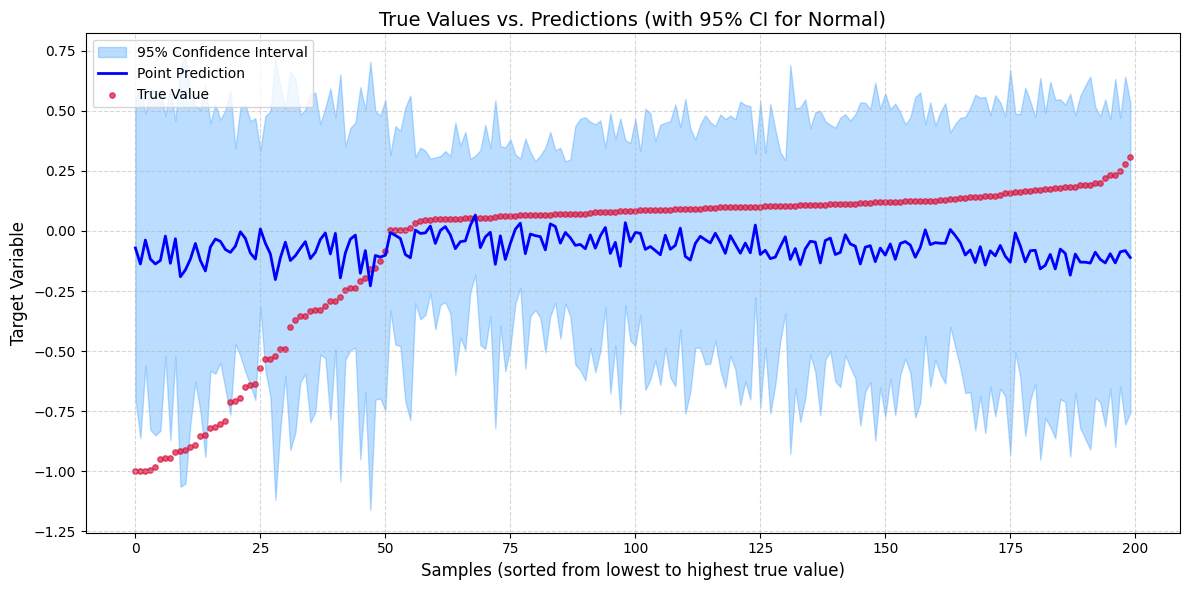

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm, laplace, t

dist_name = best_dist_str

if dist_name == "Normal":
    lower_bound = norm.ppf(0.025, loc=holdout_point, scale=holdout_std)
    upper_bound = norm.ppf(0.975, loc=holdout_point, scale=holdout_std)
elif dist_name == "Laplace":
    lower_bound = laplace.ppf(0.025, loc=holdout_point, scale=holdout_std)
    upper_bound = laplace.ppf(0.975, loc=holdout_point, scale=holdout_std)

sort_idx = np.argsort(y_val_holdout)
y_true_sorted = y_val_holdout[sort_idx]
y_pred_sorted = holdout_point[sort_idx]
lower_sorted = lower_bound[sort_idx]
upper_sorted = upper_bound[sort_idx]

plt.figure(figsize=(12, 6))
plt.fill_between(range(len(y_true_sorted)), lower_sorted, upper_sorted, 
                 color='dodgerblue', alpha=0.3, label='95% Confidence Interval')
plt.plot(range(len(y_true_sorted)), y_pred_sorted, color='blue', linewidth=2, label='Point Prediction')
plt.scatter(range(len(y_true_sorted)), y_true_sorted, color='crimson', s=15, alpha=0.7, label='True Value')
plt.title(f'True Values vs. Predictions (with 95% CI for {dist_name})', fontsize=14)
plt.xlabel('Samples (sorted from lowest to highest true value)', fontsize=12)
plt.ylabel('Target Variable', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

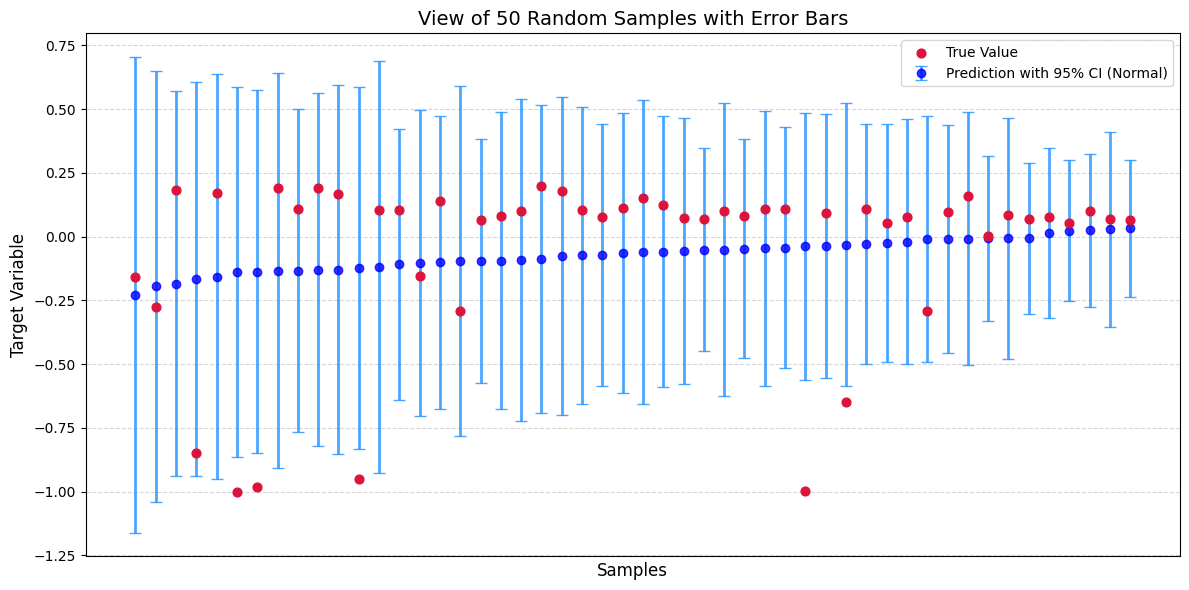

In [ ]:
n_samples = 50
sample_idx = np.random.choice(len(y_val_holdout), size=n_samples, replace=False)

y_true_sample = y_val_holdout[sample_idx]
y_pred_sample = holdout_point[sample_idx]
lower_sample = lower_bound[sample_idx]
upper_sample = upper_bound[sample_idx]

sort_idx = np.argsort(y_pred_sample)
y_true_sample = y_true_sample[sort_idx]
y_pred_sample = y_pred_sample[sort_idx]
lower_sample = lower_sample[sort_idx]
upper_sample = upper_sample[sort_idx]

yerr_lower = y_pred_sample - lower_sample
yerr_upper = upper_sample - y_pred_sample

plt.figure(figsize=(12, 6))
plt.errorbar(range(n_samples), y_pred_sample, yerr=[yerr_lower, yerr_upper], 
             fmt='o', color='blue', ecolor='dodgerblue', elinewidth=2, capsize=4, 
             alpha=0.8, label=f'Prediction with 95% CI ({dist_name})')
plt.scatter(range(n_samples), y_true_sample, color='crimson', s=40, zorder=3, label='True Value')
plt.title(f'View of {n_samples} Random Samples with Error Bars', fontsize=14)
plt.xlabel('Samples', fontsize=12)
plt.ylabel('Target Variable', fontsize=12)
plt.xticks([])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()